# 1. Introducción y Objetivo de la Preparación

En esta etapa del proyecto seguimos la metodología CRISP-DM, ubicándonos en la fase de Preparación de los Datos. El objetivo principal de este notebook es transformar y construir un dataset que esté listo para su uso en la fase de modelado, garantizando que los datos sean relevantes, consistentes y estén estructurados de manera óptima para entrenar modelos de machine learning.

Durante la fase previa (Comprensión de los Datos), identificamos múltiples fuentes de información relevantes: train.csv, test.csv, historical_transactions.csv, new_merchant_transactions.csv y merchants.csv. También detectamos distintos problemas de calidad de datos, como valores faltantes, outliers, y estructuras que requerían integrarse.

Por tanto, en esta notebook ejecutaremos las tareas necesarias para:

- Seleccionar atributos pertinentes para el modelado desde las distintas fuentes.

- Integrar adecuadamente las tablas relacionales (joins y agregaciones).

- Limpiar los datos detectados como problemáticos.

- Generar nuevas variables a partir del comportamiento transaccional de los usuarios.

- Transformar el dataset final a un formato y estructura compatibles con algoritmos de modelado.

El resultado final será un dataset preparado y curado que contenga una representación sintética de cada tarjeta (card_id), con variables numéricas y categóricas que permitan predecir de forma eficaz el loyalty score.

## Resumen de decisiones tomadas durante la fase de comprensión de los datos (por ejemplo, limpieza, selección de atributos).
Durante la fase de comprensión de los datos se analizaron las distintas fuentes de información provistas por Elo: datos de clientes (train.csv), transacciones históricas (historical_transactions.csv), transacciones recientes (new_merchant_transactions.csv) y características de los comercios (merchants.csv). Este análisis permitió identificar patrones clave, valores ausentes, relaciones entre variables y posibles outliers.

En base a los hallazgos anteriores, la fase de preparación de datos tiene como objetivo transformar estos datos crudos en un conjunto estructurado, limpio y listo para alimentar modelos de aprendizaje automático supervisado. Las principales decisiones tomadas que guían esta etapa son:

- El score de lealtad (target) es una variable continua y será predicho mediante un modelo de regresión.

- Se seleccionaron variables relevantes de cada archivo, considerando tanto su correlación potencial con la variable objetivo como su valor semántico en el contexto del negocio.

- Se detectaron variables con valores faltantes y outliers, que requerirán tratamiento adecuado.

- Se observó que muchas variables relevantes provienen de las transacciones, por lo que se realizarán agregaciones por cliente (card_id) para construir una matriz de datos con un registro por cliente.

- Las variables temporales tienen potencial para capturar estacionalidad, antigüedad y frecuencia, por lo que serán transformadas y derivadas.

- Se aplicará codificación a variables categóricas y se descartarán aquellas con baja varianza o sin valor informativo.

In [1]:
import pandas as pd
import polars as pl

import warnings
warnings.filterwarnings('ignore')

train = pl.read_csv("src/train.csv", try_parse_dates=True)
historical = pl.read_csv("src/historical_transactions.csv", try_parse_dates=True)
new_merchant = pl.read_csv("src/new_merchant_transactions.csv", try_parse_dates=True)
merchants = pl.read_csv("src/merchants.csv")

# train = pd.read_csv("src/train.csv", parse_dates=["first_active_month"])
# historical = pd.read_csv("src/historical_transactions.csv", parse_dates=["purchase_date"])
# new_merchant = pd.read_csv("src/new_merchant_transactions.csv", parse_dates=["purchase_date"])
# merchants = pd.read_csv("src/merchants.csv")

# 2. Selección de Datos

## Variables del archivo train.csv
- card_id: Identificador único del cliente. Será la clave principal para unir los datasets.

- first_active_month: Se utilizará para derivar la antigüedad del cliente.

- feature_1, feature_2: Variables categóricas internas provistas por Elo. Si bien su significado exacto no está documentado, muestran cierta variabilidad entre clientes y potencialmente capturan preferencias o segmentaciones internas.

Estas variables representan el punto de partida del cliente en la plataforma y pueden capturar segmentaciones internas o ciclos de vida que impactan en su lealtad futura.

In [2]:
train_selected = train.select(["card_id", "first_active_month", "feature_1", "feature_2", "target"])
train_selected.write_csv("src/select_data/train_selected.csv")
train_selected.head()

# train_selected = train[["card_id", "first_active_month", "feature_1", "feature_2", "target"]]
# train_selected.to_csv("src/select_data/train_selected.csv", index=False)
# train_selected.head()

card_id,first_active_month,feature_1,feature_2,target
str,str,i64,i64,f64
"""C_ID_92a2005557""","""2017-06""",5,2,-0.820283
"""C_ID_3d0044924f""","""2017-01""",4,1,0.392913
"""C_ID_d639edf6cd""","""2016-08""",2,2,0.688056
"""C_ID_186d6a6901""","""2017-09""",4,3,0.1424952
"""C_ID_cdbd2c0db2""","""2017-11""",1,3,-0.159749


## Variables derivadas del archivo historical_transactions.csv (agregadas por card_id)
- card_id
- purchase_date: Se extraerán variables de tiempo como antigüedad de la última compra, dispersión temporal entre compras y estacionalidad.
- authorized_flag: Porcentaje de transacciones aprobadas. Mide fiabilidad del cliente.
- installments: Agregado como promedio, mediana y proporción de pagos a cuotas. Refleja el tipo de consumo (efectivo vs crédito).
- merchant_category_id
- merchant_id
- purchase_amount: Se agregará como total, promedio, desviación estándar y percentiles. Mide el volumen histórico de gasto.
#### Antiguo se va eliminar
- purchase_amount: Se agregará como total, promedio, desviación estándar y percentiles. Mide el volumen histórico de gasto.

- installments: Agregado como promedio, mediana y proporción de pagos a cuotas. Refleja el tipo de consumo (efectivo vs crédito).

- purchase_date: Se extraerán variables de tiempo como antigüedad de la última compra, dispersión temporal entre compras y estacionalidad.

- month_lag: Permite agrupar transacciones por su antigüedad relativa.

- authorized_flag: Porcentaje de transacciones aprobadas. Mide fiabilidad del cliente.


Estas variables son fundamentales para entender el comportamiento histórico del cliente, sus patrones de gasto, regularidad y preferencias. Permiten inferir su valor y fidelidad previa al sistema de Elo.

In [3]:
historical_selected = historical.select([
    "card_id", 
    "purchase_date", 
    "authorized_flag", 
    "installments", 
    "merchant_category_id",
    "merchant_id", 
    "purchase_amount"
])
historical_selected.write_csv("src/select_data/historical_selected.csv")
historical_selected.head()

card_id,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount
str,datetime[μs],str,i64,i64,str,f64
"""C_ID_4e6213e9bc""",2017-06-25 15:33:07,"""Y""",0,80,"""M_ID_e020e9b302""",-0.703331
"""C_ID_4e6213e9bc""",2017-07-15 12:10:45,"""Y""",0,367,"""M_ID_86ec983688""",-0.733128
"""C_ID_4e6213e9bc""",2017-08-09 22:04:29,"""Y""",0,80,"""M_ID_979ed661fc""",-0.720386
"""C_ID_4e6213e9bc""",2017-09-02 10:06:26,"""Y""",0,560,"""M_ID_e6d5ae8ea6""",-0.735352
"""C_ID_4e6213e9bc""",2017-03-10 01:14:19,"""Y""",0,80,"""M_ID_e020e9b302""",-0.722865


In [4]:
# historical_selected = historical[
#     ["card_id", "purchase_date", "authorized_flag", "installments", "merchant_category_id",
#      "merchant_id", "purchase_amount"]
# ]
# historical_selected.to_csv("src/select_data/historical_selected.csv", index=False)

# historical_selected.head()

In [5]:
new_merchant_selected = new_merchant.select([
    "card_id", 
    "purchase_date", 
    "authorized_flag", 
    "installments", 
    "merchant_category_id",
    "merchant_id", 
    "purchase_amount"
])
new_merchant_selected.write_csv("src/select_data/new_merchant_selected.csv")
new_merchant_selected.head()

# new_merchant_selected = new_merchant[
#     ["card_id", "purchase_date", "authorized_flag", "installments", "merchant_category_id",
#      "merchant_id", "purchase_amount"]
# ]
# new_merchant_selected.to_csv("src/select_data/new_merchant_selected.csv", index=False)

# new_merchant_selected.head()

card_id,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount
str,datetime[μs],str,i64,i64,str,f64
"""C_ID_415bb3a509""",2018-03-11 14:57:36,"""Y""",1,307,"""M_ID_b0c793002c""",-0.557574
"""C_ID_415bb3a509""",2018-03-19 18:53:37,"""Y""",1,307,"""M_ID_88920c89e8""",-0.56958
"""C_ID_415bb3a509""",2018-04-26 14:08:44,"""Y""",1,507,"""M_ID_ad5237ef6b""",-0.551037
"""C_ID_415bb3a509""",2018-03-07 09:43:21,"""Y""",1,661,"""M_ID_9e84cda3b1""",-0.671925
"""C_ID_ef55cf8d4b""",2018-03-22 21:07:53,"""Y""",1,166,"""M_ID_3c86fa3831""",-0.659904


## Variables derivadas del archivo merchants.csv
- Misma estructura y tratamiento que historical_transactions, pero se analizarán como indicadores de comportamiento reciente (últimos comercios visitados).

Permiten medir el comportamiento del cliente frente a nuevos comercios, lo que es clave para inferir respuesta a campañas, apertura al cambio y potencial de exploración comercial. Clientes activos con nuevos comercios pueden tener mayor probabilidad de lealtad futura.

## Variables del archivo merchants.csv (vinculadas vía merchant_id)
- merchant_id
- merchant_group_id
- merchant_category_id
- most_recent_sales_range: Codifican la intensidad comercial más reciente. Se codificarán ordinalmente.
- most_recent_purchases_range: Codifican la intensidad comercial más reciente. Se codificarán ordinalmente.
- active_months_lag12: Cantidad de meses activos en los últimos 12 meses
#### Antiguo se va eliminar
- avg_sales_lag3, avg_sales_lag6, etc.: Indicadores del dinamismo del comercio.

- most_recent_sales_range, most_recent_purchases_range: Codifican la intensidad comercial más reciente. Se codificarán ordinalmente.

- merchant_category_id, category_1, category_4: Se cruzarán con las transacciones para crear representaciones de afinidad del cliente con ciertas categorías o tipos de comercio.

El tipo de comercio influye en el patrón de compra del cliente. Al cruzarlo con los hábitos del cliente, se pueden obtener variables que midan la compatibilidad cliente–comercio.

In [6]:
merchants_selected = merchants.select([
    "merchant_id",
    "merchant_group_id",
    "merchant_category_id",
    "most_recent_sales_range",
    "most_recent_purchases_range",
    "active_months_lag12"
])
merchants_selected.write_csv("src/select_data/merchants_selected.csv")
merchants_selected.head()

# merchants_selected = merchants[
#     ["merchant_id", "merchant_group_id", "merchant_category_id", "most_recent_sales_range", 
#      "most_recent_purchases_range", "active_months_lag12"]
# ]
# merchants_selected.to_csv("src/select_data/merchants_selected.csv", index=False)

# merchants_selected.head()

merchant_id,merchant_group_id,merchant_category_id,most_recent_sales_range,most_recent_purchases_range,active_months_lag12
str,i64,i64,str,str,i64
"""M_ID_838061e48c""",8353,792,"""E""","""E""",12
"""M_ID_9339d880ad""",3184,840,"""E""","""E""",12
"""M_ID_e726bbae1e""",447,690,"""E""","""E""",2
"""M_ID_a70e9c5f81""",5026,792,"""E""","""E""",12
"""M_ID_64456c37ce""",2228,222,"""E""","""E""",12


## Variables descartadas o no priorizadas
- subsector_id, category_name: Alta cardinalidad, bajo control semántico. Serán descartadas a menos que pruebas futuras muestren valor predictivo.

- Variables como merchant_id y merchant_group_id no se usarán directamente, pero servirán como llaves de agregación.

- Transacciones no autorizadas: Si representan un porcentaje muy pequeño (<5%), pueden ser descartadas por ruido.

- Variables con más del 90% de valores nulos o con baja varianza.

## Enfoque adicional orientado al producto
- Clientes con gran diversidad de categorías y alta frecuencia reciente podrían representar perfiles altamente leales o promotores. Este tipo de hipótesis será validada en el modelado.

- Se prestará atención a variables que permitan explicar no solo el monto gastado, sino el nivel de compromiso con la plataforma, como uso recurrente, exploración de nuevos comercios y respuesta a promociones.

# 3. Limpieza de los Datos

## Imputación de valores faltantes.
La imputación de valores faltantes es una técnica utilizada en la limpieza de datos para reemplazar los valores ausentes (NaN o null) en un dataset por valores estimados o calculados. El objetivo es evitar perder información valiosa y permitir que los algoritmos de análisis o modelado funcionen correctamente, ya que muchos no pueden manejar datos faltantes.

In [7]:
def verificar_nulos(df, nombre):
    print(f"\nValores nulos en: {nombre}")
    nulos = df.null_count().to_dict(as_series=False)
    # Si los valores son listas, extrae el primer elemento
    print({col: (val[0] if isinstance(val, list) else val) for col, val in nulos.items()})
    
    


# def mostrar_nulos(df, nombre):
#     print(f"\nValores nulos en: {nombre}")
#     existe_nulos = df.isnull().sum().sum() > 0
#     print(df.isnull().sum()[df.isnull().sum() > 0] if existe_nulos else "No se encontraron valores nulos en el dataset")


In [8]:
verificar_nulos(train_selected, "train_selected")
verificar_nulos(historical_selected, "historical_selected")
verificar_nulos(new_merchant_selected, "new_merchant_selected")
verificar_nulos(merchants_selected, "merchants_selected")

# mostrar_nulos(train_selected, "train_selected")
# mostrar_nulos(historical_selected, "historical_selected")
# mostrar_nulos(new_merchant_selected, "new_merchant_selected")
# mostrar_nulos(merchants_selected, "merchants_selected")



Valores nulos en: train_selected
{'card_id': 0, 'first_active_month': 0, 'feature_1': 0, 'feature_2': 0, 'target': 0}

Valores nulos en: historical_selected
{'card_id': 0, 'purchase_date': 0, 'authorized_flag': 0, 'installments': 0, 'merchant_category_id': 0, 'merchant_id': 138481, 'purchase_amount': 0}

Valores nulos en: new_merchant_selected
{'card_id': 0, 'purchase_date': 0, 'authorized_flag': 0, 'installments': 0, 'merchant_category_id': 0, 'merchant_id': 26216, 'purchase_amount': 0}

Valores nulos en: merchants_selected
{'merchant_id': 0, 'merchant_group_id': 0, 'merchant_category_id': 0, 'most_recent_sales_range': 0, 'most_recent_purchases_range': 0, 'active_months_lag12': 0}


### **Tratamiento de nulos en historical_selected**

In [9]:
def generar_moda(dataframe):
    df_freq = (
        dataframe
        .group_by(["card_id", "merchant_id"])
        .agg(pl.count().alias("count"))
    )
        
    df_mode = (
        df_freq
        .sort(["card_id", "count", "merchant_id"], descending=[False, True, True])
        .group_by("card_id")
        .agg(pl.col("merchant_id").first().alias("merchant_id_moda"))
    )

    return df_mode

df_mode_historical = generar_moda(historical_selected)
df_mode_historical.head(10)

card_id,merchant_id_moda
str,str
"""C_ID_00007093c1""","""M_ID_9400cf2342"""
"""C_ID_0001238066""","""M_ID_d17aabd756"""
"""C_ID_0001506ef0""","""M_ID_b1fc88154d"""
"""C_ID_0001793786""","""M_ID_923d57de8d"""
"""C_ID_000183fdda""","""M_ID_f9cfe0a43b"""
"""C_ID_00024e244b""","""M_ID_8f71be2af9"""
"""C_ID_0002709b5a""","""M_ID_543dd11ce2"""
"""C_ID_00027503e2""","""M_ID_8de747a1c2"""
"""C_ID_000298032a""","""M_ID_8978193c15"""


In [10]:
def reemplazar_moda_in_transactions(dataframe_original, df_mode):
    # Selecciona solo las columnas necesarias (sin persist ni count)
    df_moda_util = df_mode.select(['card_id', 'merchant_id_moda'])

    # Realiza el join usando Polars
    vdf_final = dataframe_original.join(df_moda_util, on="card_id", how="left")

    # Si merchant_id es nulo, reemplázalo por merchant_id_moda
    vdf_final = vdf_final.with_columns([
        pl.when(pl.col("merchant_id").is_null())
        .then(pl.col("merchant_id_moda"))
        .otherwise(pl.col("merchant_id"))
        .alias("merchant_id")
    ]).drop("merchant_id_moda")
    
    return vdf_final

In [11]:
vdf_historical = reemplazar_moda_in_transactions(historical_selected, df_mode_historical)
verificar_nulos(vdf_historical, "vdf_historical")


Valores nulos en: vdf_historical
{'card_id': 0, 'purchase_date': 0, 'authorized_flag': 0, 'installments': 0, 'merchant_category_id': 0, 'merchant_id': 6262, 'purchase_amount': 0}


In [12]:
# # mostrar de vdf_historical solo los que tengan merchant_id nulo
# vdf_historical_nulls = vdf_historical.filter(pl.col("merchant_id").is_null())
# # de vdf_historical, verificar si se repiten el card_id
# vdf_historical_repeated = vdf_historical_nulls.group_by("card_id").agg(pl.count().alias("count")).filter(pl.col("count") > 1)
# #vdf_historical_repeated

# # mostrar en una tabla los registros que tengan de card_id = "C_ID_69470cbe80" de vdf_historical_nulls
# #vdf_historical_nulls.filter(pl.col("card_id") == "C_ID_69470cbe80")

# Eliminar todas las filas que tengan merchant_id nulo de vdf_historical
vdf_historical = vdf_historical.filter(pl.col("merchant_id").is_not_null())
vdf_historical



card_id,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount
str,datetime[μs],str,i64,i64,str,f64
"""C_ID_4e6213e9bc""",2017-06-25 15:33:07,"""Y""",0,80,"""M_ID_e020e9b302""",-0.703331
"""C_ID_4e6213e9bc""",2017-07-15 12:10:45,"""Y""",0,367,"""M_ID_86ec983688""",-0.733128
"""C_ID_4e6213e9bc""",2017-08-09 22:04:29,"""Y""",0,80,"""M_ID_979ed661fc""",-0.720386
"""C_ID_4e6213e9bc""",2017-09-02 10:06:26,"""Y""",0,560,"""M_ID_e6d5ae8ea6""",-0.735352
"""C_ID_4e6213e9bc""",2017-03-10 01:14:19,"""Y""",0,80,"""M_ID_e020e9b302""",-0.722865
…,…,…,…,…,…,…
"""C_ID_2863d2fa95""",2017-01-20 08:52:04,"""Y""",1,360,"""M_ID_edd92b6720""",-0.632706
"""C_ID_2863d2fa95""",2017-02-20 04:40:50,"""Y""",1,360,"""M_ID_edd92b6720""",-0.632706
"""C_ID_5c240d6e3c""",2017-12-26 18:37:51,"""Y""",0,278,"""M_ID_9cdcfe8673""",-0.65774


Verificamos la limpieza

In [13]:
verificar_nulos(vdf_historical, "vdf_historical sin nulos en merchant_id")


Valores nulos en: vdf_historical sin nulos en merchant_id
{'card_id': 0, 'purchase_date': 0, 'authorized_flag': 0, 'installments': 0, 'merchant_category_id': 0, 'merchant_id': 0, 'purchase_amount': 0}


### **Tratamiento de nulos en new_merchant_selected**

In [14]:
df_mode_new_historical = generar_moda(new_merchant_selected)
df_mode_new_historical.head(10)

card_id,merchant_id_moda
str,str
"""C_ID_00007093c1""","""M_ID_08f01305af"""
"""C_ID_0001238066""",null
"""C_ID_0001506ef0""",null
"""C_ID_0001793786""","""M_ID_f86439cec0"""
"""C_ID_000183fdda""","""M_ID_f7197e94a6"""
"""C_ID_0002709b5a""","""M_ID_bee1dd91a9"""
"""C_ID_000298032a""","""M_ID_c33d6e0856"""
"""C_ID_0002ba3c2e""","""M_ID_f598656829"""
"""C_ID_0002c7c2c1""","""M_ID_d74eeb0c7a"""


In [15]:
vdf_new_historical = reemplazar_moda_in_transactions(historical_selected, df_mode_new_historical)
verificar_nulos(vdf_new_historical, "vdf_new_historical")


Valores nulos en: vdf_new_historical
{'card_id': 0, 'purchase_date': 0, 'authorized_flag': 0, 'installments': 0, 'merchant_category_id': 0, 'merchant_id': 6053, 'purchase_amount': 0}


In [16]:
vdf_new_historical = vdf_new_historical.filter(pl.col("merchant_id").is_not_null())
vdf_new_historical

card_id,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount
str,datetime[μs],str,i64,i64,str,f64
"""C_ID_4e6213e9bc""",2017-06-25 15:33:07,"""Y""",0,80,"""M_ID_e020e9b302""",-0.703331
"""C_ID_4e6213e9bc""",2017-07-15 12:10:45,"""Y""",0,367,"""M_ID_86ec983688""",-0.733128
"""C_ID_4e6213e9bc""",2017-08-09 22:04:29,"""Y""",0,80,"""M_ID_979ed661fc""",-0.720386
"""C_ID_4e6213e9bc""",2017-09-02 10:06:26,"""Y""",0,560,"""M_ID_e6d5ae8ea6""",-0.735352
"""C_ID_4e6213e9bc""",2017-03-10 01:14:19,"""Y""",0,80,"""M_ID_e020e9b302""",-0.722865
…,…,…,…,…,…,…
"""C_ID_2863d2fa95""",2017-01-20 08:52:04,"""Y""",1,360,"""M_ID_edd92b6720""",-0.632706
"""C_ID_2863d2fa95""",2017-02-20 04:40:50,"""Y""",1,360,"""M_ID_edd92b6720""",-0.632706
"""C_ID_5c240d6e3c""",2017-12-26 18:37:51,"""Y""",0,278,"""M_ID_9cdcfe8673""",-0.65774


Verificamos la limpieza

In [17]:
verificar_nulos(vdf_new_historical, "vdf_historical sin nulos en merchant_id")


Valores nulos en: vdf_historical sin nulos en merchant_id
{'card_id': 0, 'purchase_date': 0, 'authorized_flag': 0, 'installments': 0, 'merchant_category_id': 0, 'merchant_id': 0, 'purchase_amount': 0}


### Validacion de existencias de claves foraneas en historical

In [18]:
def verificar_merchants_existentes(vdf_historical_unique, merchants_selected):
    missing_merchants = vdf_historical_unique.filter(
        ~pl.col("merchant_id").is_in(merchants_selected["merchant_id"])
    )
    return missing_merchants

In [19]:
def verificar_cards_existentes(vdf_historical_unique, train_selected):
    missing_cards = vdf_historical_unique.filter(
        ~pl.col("card_id").is_in(train_selected["card_id"])
    )
    return missing_cards

In [20]:
# del dataframe vdf_historical crear una nueva tabla que contenga todos los merchant_id sin duplicados
vdf_historical_unique_merchants = (
    vdf_historical
    .select("merchant_id")
    .unique()
)


missing_merchants = verificar_merchants_existentes(vdf_historical_unique_merchants, merchants_selected)

print("Todos los merchant_id de Historical existen"if missing_merchants.is_empty() else "Hay merchant_id de Historical que no existen en Merchants")



Todos los merchant_id de Historical existen


Se verificco la existencia de todos los merchant_id de historical, por lo cual no necesita de una limpieza

In [21]:
# del dataframe vdf_historical crear una nueva tabla que contenga todos los merchant_id sin duplicados
vdf_historical_unique_cards = (
    vdf_historical
    .select("card_id")
    .unique()
)

missing_cards = verificar_cards_existentes(train_selected, vdf_historical_unique_cards)

print("Todos los card_id de Historical existen"if missing_cards.is_empty() else "Hay card_id de Historical que no existen en Train")



Todos los card_id de Historical existen


### Validacion de existencias de claves foraneas en new historical

In [22]:

vdf_new_historical_unique_merchants = (
    vdf_new_historical
    .select("merchant_id")
    .unique()
)

missing_merchants_new = verificar_merchants_existentes(vdf_new_historical_unique_merchants, merchants_selected)

print("Todos los merchant_id de Historical existen"if missing_merchants_new.is_empty() else "Hay merchant_id de Historical que no existen en Merchants")


Todos los merchant_id de Historical existen


Se verificco la existencia de todos los merchant_id de new historical, por lo cual no necesita de una limpieza

In [23]:
# del dataframe vdf_historical crear una nueva tabla que contenga todos los merchant_id sin duplicados
vdf_new_historical_unique_cards = (
    vdf_new_historical
    .select("card_id")
    .unique()
)

missing_cards_new = verificar_cards_existentes(train_selected, vdf_new_historical_unique_cards)

print("Todos los card_id de Historical existen"if missing_cards_new.is_empty() else "Hay card_id de Historical que no existen en Train")



Todos los card_id de Historical existen


Guardamos el dataset 

In [24]:
vdf_historical.write_csv("src/clean_data/vdf_historical.csv")
vdf_new_historical.write_csv("src/clean_data/vdf_new_historical.csv")
train_selected.write_csv("src/clean_data/train_selected.csv")
merchants_selected.write_csv("src/clean_data/merchants_selected.csv")

## Corrección de valores erróneos, inconsistentes o duplicados.

In [ ]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
# Cargar los datos limpios
vdf_historical = pl.read_csv("src/clean_data/vdf_historical.csv", try_parse_dates=True)
vdf_new_historical = pl.read_csv("src/clean_data/vdf_new_historical.csv", try_parse_dates=True)
train_selected = pl.read_csv("src/clean_data/train_selected.csv", try_parse_dates=True)
merchants_selected = pl.read_csv("src/clean_data/merchants_selected.csv")

transaction = pl.concat([vdf_historical, vdf_new_historical], how="vertical")

In [7]:
import matplotlib.pyplot as plt
# crea una funcion para identificar filas duplicadas en un mismo dataframe de polars que recibe por parametro el dataframe
def identificar_duplicados(dataframe):
    duplicados = dataframe.group_by(dataframe.columns).agg(pl.count().alias("count")).filter(pl.col("count") > 1)
    return duplicados

# funcion que seleciona un dataframe y selecciona por un campo "date" para seleccionar el rango de fechas 2017-11 hasta 2018-04. Los parametros son "df" y "nombre_columna_fecha"
def filtrar_por_fecha(df, nombre_columna_fecha):
    fecha_inicio = pl.lit("2017-11-01").str.strptime(pl.Date)
    fecha_fin = pl.lit("2018-04-30").str.strptime(pl.Date)
    
    df_filtrado = df.filter(
        (pl.col(nombre_columna_fecha) >= fecha_inicio) & 
        (pl.col(nombre_columna_fecha) <= fecha_fin)
    )
    
    return df_filtrado

def eliminar_duplicados(dataframe):
    return dataframe.unique(subset=dataframe.columns)

def generar_boxplot(dataframe, column_name, title):
    plt.figure(figsize=(10, 6))
    dataframe.select(column_name).to_pandas().boxplot()
    plt.title(title)
    plt.ylabel(column_name)
    plt.show()


In [3]:
transaction = filtrar_por_fecha(transaction, "purchase_date")
transaction

card_id,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount
str,datetime[μs],str,i64,i64,str,f64
"""C_ID_4e6213e9bc""",2018-02-24 08:45:05,"""Y""",0,80,"""M_ID_50af771f8d""",-0.734887
"""C_ID_4e6213e9bc""",2017-11-18 20:05:55,"""Y""",0,80,"""M_ID_9d41786a50""",-0.657049
"""C_ID_4e6213e9bc""",2018-02-08 20:05:45,"""Y""",0,560,"""M_ID_7c5e93af2f""",-0.727929
"""C_ID_4e6213e9bc""",2018-02-07 12:19:33,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.725871
"""C_ID_4e6213e9bc""",2018-01-08 23:54:29,"""Y""",0,80,"""M_ID_4524a562f3""",-0.699725
…,…,…,…,…,…,…
"""C_ID_e49b1996b0""",2017-12-29 14:43:53,"""Y""",1,705,"""M_ID_b692f6f5d1""",-0.618747
"""C_ID_e49b1996b0""",2018-01-23 01:52:28,"""Y""",1,550,"""M_ID_09d7a200d1""",-0.656749
"""C_ID_e49b1996b0""",2018-02-07 18:17:01,"""Y""",1,130,"""M_ID_ea5d727248""",-0.694315


In [4]:
print(identificar_duplicados(train_selected))
print(identificar_duplicados(transaction))
print(identificar_duplicados(merchants_selected))

shape: (0, 6)
┌─────────┬────────────────────┬───────────┬───────────┬────────┬───────┐
│ card_id ┆ first_active_month ┆ feature_1 ┆ feature_2 ┆ target ┆ count │
│ ---     ┆ ---                ┆ ---       ┆ ---       ┆ ---    ┆ ---   │
│ str     ┆ str                ┆ i64       ┆ i64       ┆ f64    ┆ u32   │
╞═════════╪════════════════════╪═══════════╪═══════════╪════════╪═══════╡
└─────────┴────────────────────┴───────────┴───────────┴────────┴───────┘
shape: (11_388_993, 8)
┌────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────┐
│ card_id    ┆ purchase_d ┆ authorized ┆ installmen ┆ merchant_c ┆ merchant_i ┆ purchase_a ┆ count │
│ ---        ┆ ate        ┆ _flag      ┆ ts         ┆ ategory_id ┆ d          ┆ mount      ┆ ---   │
│ str        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ u32   │
│            ┆ datetime[μ ┆ str        ┆ i64        ┆ i64        ┆ str        ┆ f64        ┆       │
│            ┆

In [14]:
train_selected = eliminar_duplicados(train_selected)
transaction = eliminar_duplicados(transaction)
merchants_selected = eliminar_duplicados(merchants_selected)

In [15]:
print(identificar_duplicados(train_selected))
print(identificar_duplicados(transaction))
print(identificar_duplicados(merchants_selected))

shape: (0, 6)
┌─────────┬────────────────────┬───────────┬───────────┬────────┬───────┐
│ card_id ┆ first_active_month ┆ feature_1 ┆ feature_2 ┆ target ┆ count │
│ ---     ┆ ---                ┆ ---       ┆ ---       ┆ ---    ┆ ---   │
│ str     ┆ str                ┆ i64       ┆ i64       ┆ f64    ┆ u32   │
╞═════════╪════════════════════╪═══════════╪═══════════╪════════╪═══════╡
└─────────┴────────────────────┴───────────┴───────────┴────────┴───────┘
shape: (0, 8)
┌─────────┬─────────────┬─────────────┬─────────────┬────────────┬────────────┬────────────┬───────┐
│ card_id ┆ purchase_da ┆ authorized_ ┆ installment ┆ merchant_c ┆ merchant_i ┆ purchase_a ┆ count │
│ ---     ┆ te          ┆ flag        ┆ s           ┆ ategory_id ┆ d          ┆ mount      ┆ ---   │
│ str     ┆ ---         ┆ ---         ┆ ---         ┆ ---        ┆ ---        ┆ ---        ┆ u32   │
│         ┆ datetime[μs ┆ str         ┆ i64         ┆ i64        ┆ str        ┆ f64        ┆       │
│         ┆ ]          

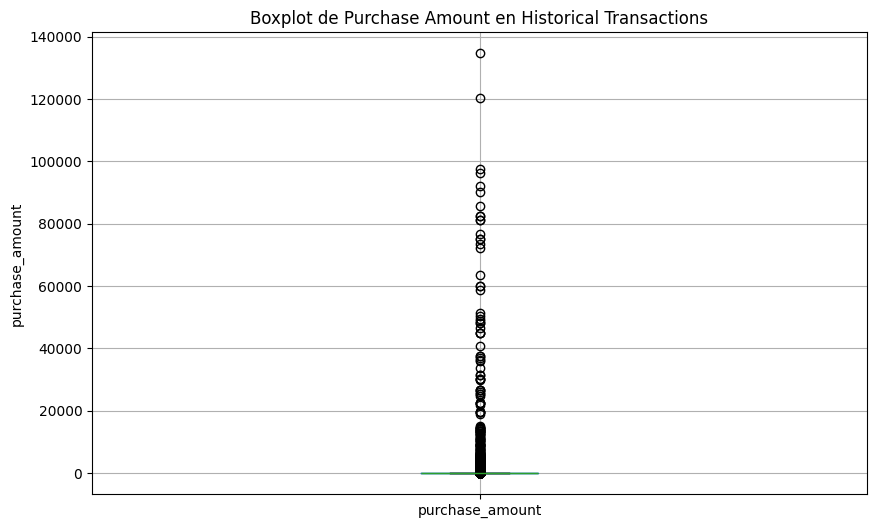

In [20]:
generar_boxplot(transaction, "purchase_amount", "Boxplot de Purchase Amount en Historical Transactions")

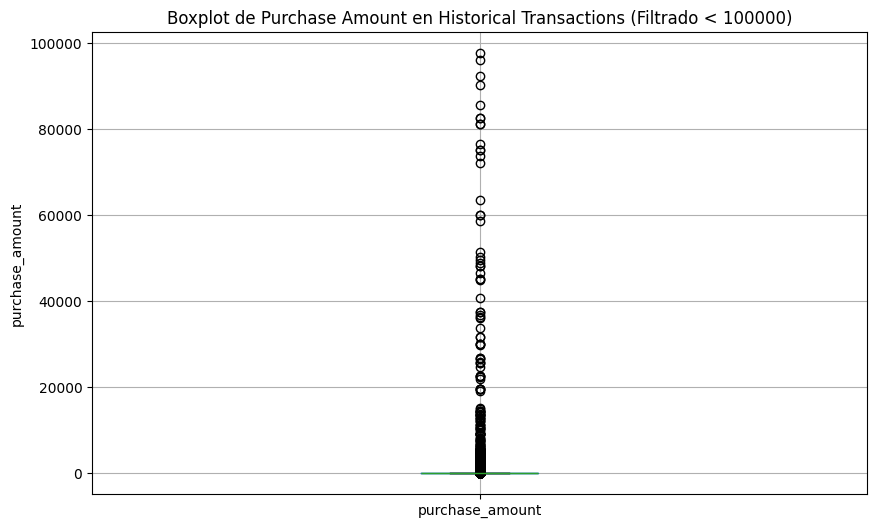

In [25]:
# seleccionar todas las filas que sean menores a 100000 de purchase_amount del dataframe transaction
transaction = transaction.filter(pl.col("purchase_amount") < 100000)
generar_boxplot(transaction, "purchase_amount", "Boxplot de Purchase Amount en Historical Transactions (Filtrado < 100000)")

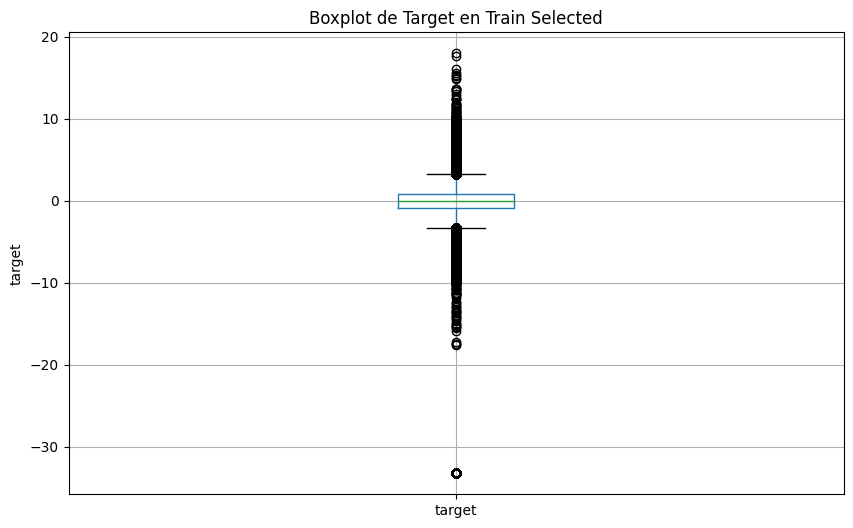

In [22]:
generar_boxplot(train_selected, "target", "Boxplot de Target en Train Selected")

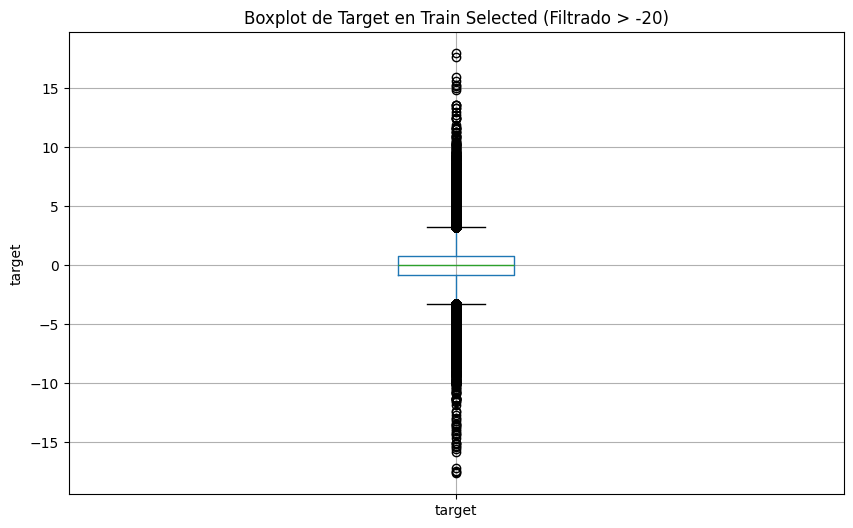

In [24]:
train_selected = train_selected.filter(pl.col("target") > -20)
generar_boxplot(train_selected, "target", "Boxplot de Target en Train Selected (Filtrado > -20)")

In [27]:
# guardar los dataframes finales
transaction.write_csv("src/final_data/transaction.csv")
train_selected.write_csv("src/final_data/train_selected.csv")
merchants_selected.write_csv("src/final_data/merchants_selected.csv")

In [24]:
# SELECCIONAR LA COLUMNA DE CARD_ID DE train_selected
train_card_ids = merchants_selected.select("merchant_id")

print(identificar_duplicados(train_card_ids))


shape: (41, 2)
┌─────────────────┬───────┐
│ merchant_id     ┆ count │
│ ---             ┆ ---   │
│ str             ┆ u32   │
╞═════════════════╪═══════╡
│ M_ID_645a6af169 ┆ 2     │
│ M_ID_a8767b29ef ┆ 2     │
│ M_ID_992a180b15 ┆ 4     │
│ M_ID_49b779bc8a ┆ 2     │
│ M_ID_00a6ca8a8a ┆ 2     │
│ …               ┆ …     │
│ M_ID_9b0ef314cf ┆ 2     │
│ M_ID_a55beb9d9a ┆ 2     │
│ M_ID_d123532c72 ┆ 4     │
│ M_ID_7251df88ad ┆ 2     │
│ M_ID_ebbdb42da6 ┆ 4     │
└─────────────────┴───────┘


In [8]:
# funcion que seleciona un dataframe y selecciona por un campo "date" para seleccionar el rango de fechas 2017-11 hasta 2018-04. Los parametros son "df" y "nombre_columna_fecha"
def filtrar_por_fecha(df, nombre_columna_fecha):
    fecha_inicio = pl.lit("2017-11-01").str.strptime(pl.Date)
    fecha_fin = pl.lit("2018-04-30").str.strptime(pl.Date)
    
    df_filtrado = df.filter(
        (pl.col(nombre_columna_fecha) >= fecha_inicio) & 
        (pl.col(nombre_columna_fecha) <= fecha_fin)
    )
    
    return df_filtrado

vdf_historical = filtrar_por_fecha(vdf_historical, "purchase_date")
vdf_new_historical = filtrar_por_fecha(vdf_new_historical, "purchase_date")


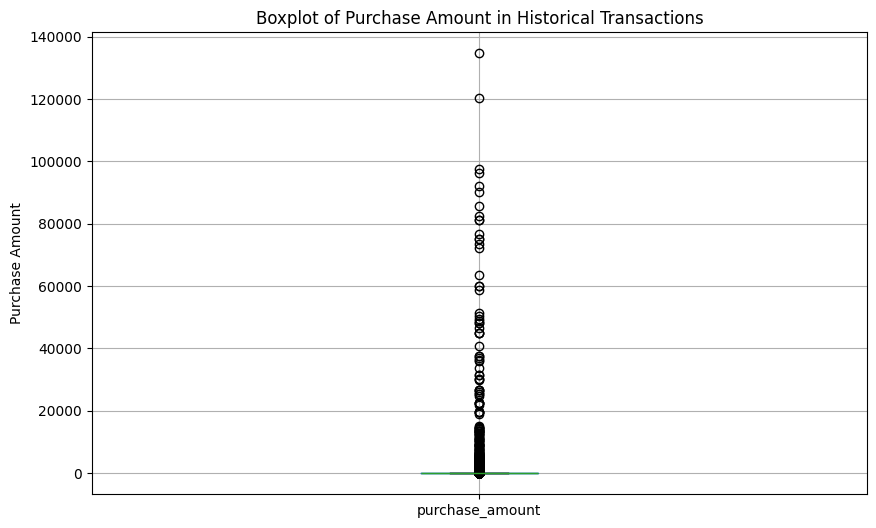

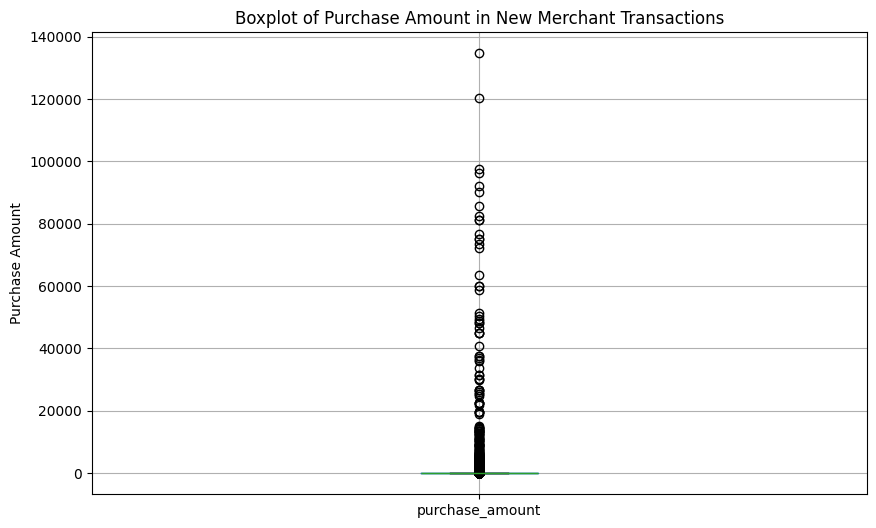

In [ ]:
#genera boxplots de la columana purchase_amount del dataframe de polars de vdf_historical y vdf_new_historical
import matplotlib.pyplot as plt
def generar_boxplot(dataframe, column, title):
    plt.figure(figsize=(10, 6))
    dataframe.select(column).to_pandas().boxplot()
    plt.title(title)
    plt.ylabel("Purchase Amount")
    plt.show()
generar_boxplot(vdf_historical, "Boxplot of Purchase Amount in Historical Transactions")
generar_boxplot(vdf_new_historical, "Boxplot of Purchase Amount in New Merchant Transactions")



In [11]:
print(identificar_duplicados(vdf_historical))
print(identificar_duplicados(vdf_new_historical))

shape: (85, 8)
┌────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────┐
│ card_id    ┆ purchase_d ┆ authorized ┆ installmen ┆ merchant_c ┆ merchant_i ┆ purchase_a ┆ count │
│ ---        ┆ ate        ┆ _flag      ┆ ts         ┆ ategory_id ┆ d          ┆ mount      ┆ ---   │
│ str        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ u32   │
│            ┆ datetime[μ ┆ str        ┆ i64        ┆ i64        ┆ str        ┆ f64        ┆       │
│            ┆ s]         ┆            ┆            ┆            ┆            ┆            ┆       │
╞════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═══════╡
│ C_ID_0041c ┆ 2017-11-03 ┆ N          ┆ 1          ┆ 705        ┆ M_ID_e3006 ┆ -0.68004   ┆ 2     │
│ 3242c      ┆ 00:00:00   ┆            ┆            ┆            ┆ 08e50      ┆            ┆       │
│ C_ID_cbe12 ┆ 2017-11-11 ┆ N          ┆ 0          ┆ 705        ┆ M_ID_b98d

In [12]:
# aplica el metodo de robus scaling para estandarizar la columna purchase_amount de vdf_historical y vdf_new_historical
from sklearn.preprocessing import RobustScaler
def aplicar_robust_scaler(dataframe):
    scaler = RobustScaler()
    # Convertir la columna a un formato adecuado para el escalado
    purchase_amount = dataframe.select("purchase_amount").to_pandas().values.reshape(-1, 1)
    # Aplicar el escalado
    scaled_values = scaler.fit_transform(purchase_amount)
    # Reemplazar la columna original con los valores escalados
    dataframe = dataframe.with_columns(pl.Series("purchase_amount", scaled_values.flatten()))
    return dataframe
vdf_historical = aplicar_robust_scaler(vdf_historical)
vdf_new_historical = aplicar_robust_scaler(vdf_new_historical)

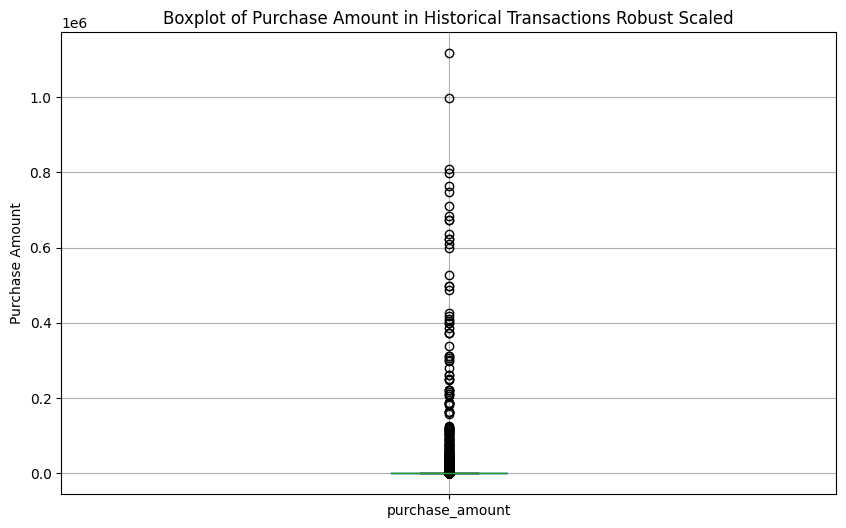

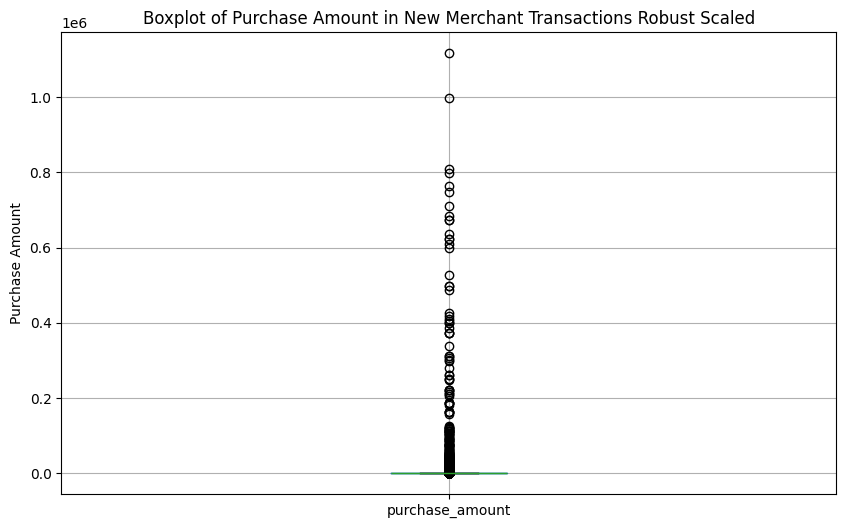

In [13]:
generar_boxplot(vdf_historical, "Boxplot of Purchase Amount in Historical Transactions Robust Scaled")
generar_boxplot(vdf_new_historical, "Boxplot of Purchase Amount in New Merchant Transactions Robust Scaled")

In [12]:
# funcion para eliminar duplicados en un dataframe de polars
def eliminar_duplicados(dataframe):
    return dataframe.unique(subset=dataframe.columns)
train_selected =eliminar_duplicados(train_selected)
vdf_historical =eliminar_duplicados(vdf_historical)
vdf_new_historical =eliminar_duplicados(vdf_new_historical)
merchants_selected = eliminar_duplicados(merchants_selected)

# # funcion para elimiar filas donde tienen el mismo merchant_id de un dataframe de polars
# def eliminar_duplicados_por_merchant_id(dataframe):
#     return dataframe.unique(subset=["merchant_id"])

# df_clean2 = eliminar_duplicados(merchants_selected)


In [ ]:
print(identificar_duplicados(train_selected))
print(identificar_duplicados(vdf_historical))
print(identificar_duplicados(vdf_new_historical))
print(identificar_duplicados(merchants_selected))

shape: (0, 7)
┌─────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬───────┐
│ merchant_id ┆ merchant_grou ┆ merchant_cate ┆ most_recent_ ┆ most_recent_ ┆ active_month ┆ count │
│ ---         ┆ p_id          ┆ gory_id       ┆ sales_range  ┆ purchases_ra ┆ s_lag12      ┆ ---   │
│ str         ┆ ---           ┆ ---           ┆ ---          ┆ nge          ┆ ---          ┆ u32   │
│             ┆ i64           ┆ i64           ┆ str          ┆ ---          ┆ i64          ┆       │
│             ┆               ┆               ┆              ┆ str          ┆              ┆       │
╞═════════════╪═══════════════╪═══════════════╪══════════════╪══════════════╪══════════════╪═══════╡
└─────────────┴───────────────┴───────────────┴──────────────┴──────────────┴──────────────┴───────┘
shape: (0, 7)
┌─────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬───────┐
│ merchant_id ┆ merchant_grou ┆ merchant_cate ┆ most_recent_ ┆ 

In [ ]:
# buscar por merchant_id en dataframe df_clean
def buscar_por_merchant_id(dataframe, merchant_id):
    return dataframe.filter(pl.col("merchant_id") == merchant_id)   

buscar_por_merchant_id(merchants_selected, 'M_ID_6464db3b45')

merchant_id,merchant_group_id,merchant_category_id,most_recent_sales_range,most_recent_purchases_range,active_months_lag12
str,i64,i64,str,str,i64
"""M_ID_6464db3b45""",3604,210,"""A""","""C""",12
"""M_ID_6464db3b45""",35,210,"""A""","""C""",12


## Detección y tratamiento de outliers.

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

columnas_train = ["feature_1", "feature_2", "feature_3", "target"]
columnas_hist = ["purchase_amount", "installments", "month_lag"]
columnas_merchant = [
    "avg_sales_lag3", "avg_sales_lag6", "avg_sales_lag12",
    "avg_purchases_lag3", "avg_purchases_lag6", "avg_purchases_lag12"
]


In [50]:
def graficar_boxplots(df, columnas, titulo):
    filas = (len(columnas) + 2) // 3
    plt.figure(figsize=(15, 5 * filas))
    for i, col in enumerate(columnas, 1):
        plt.subplot(filas, 3, i)
        sns.boxplot(x=df[col], color="skyblue", fliersize=3)
        plt.title(f"{titulo} - {col}")
        plt.tight_layout()
    plt.show()


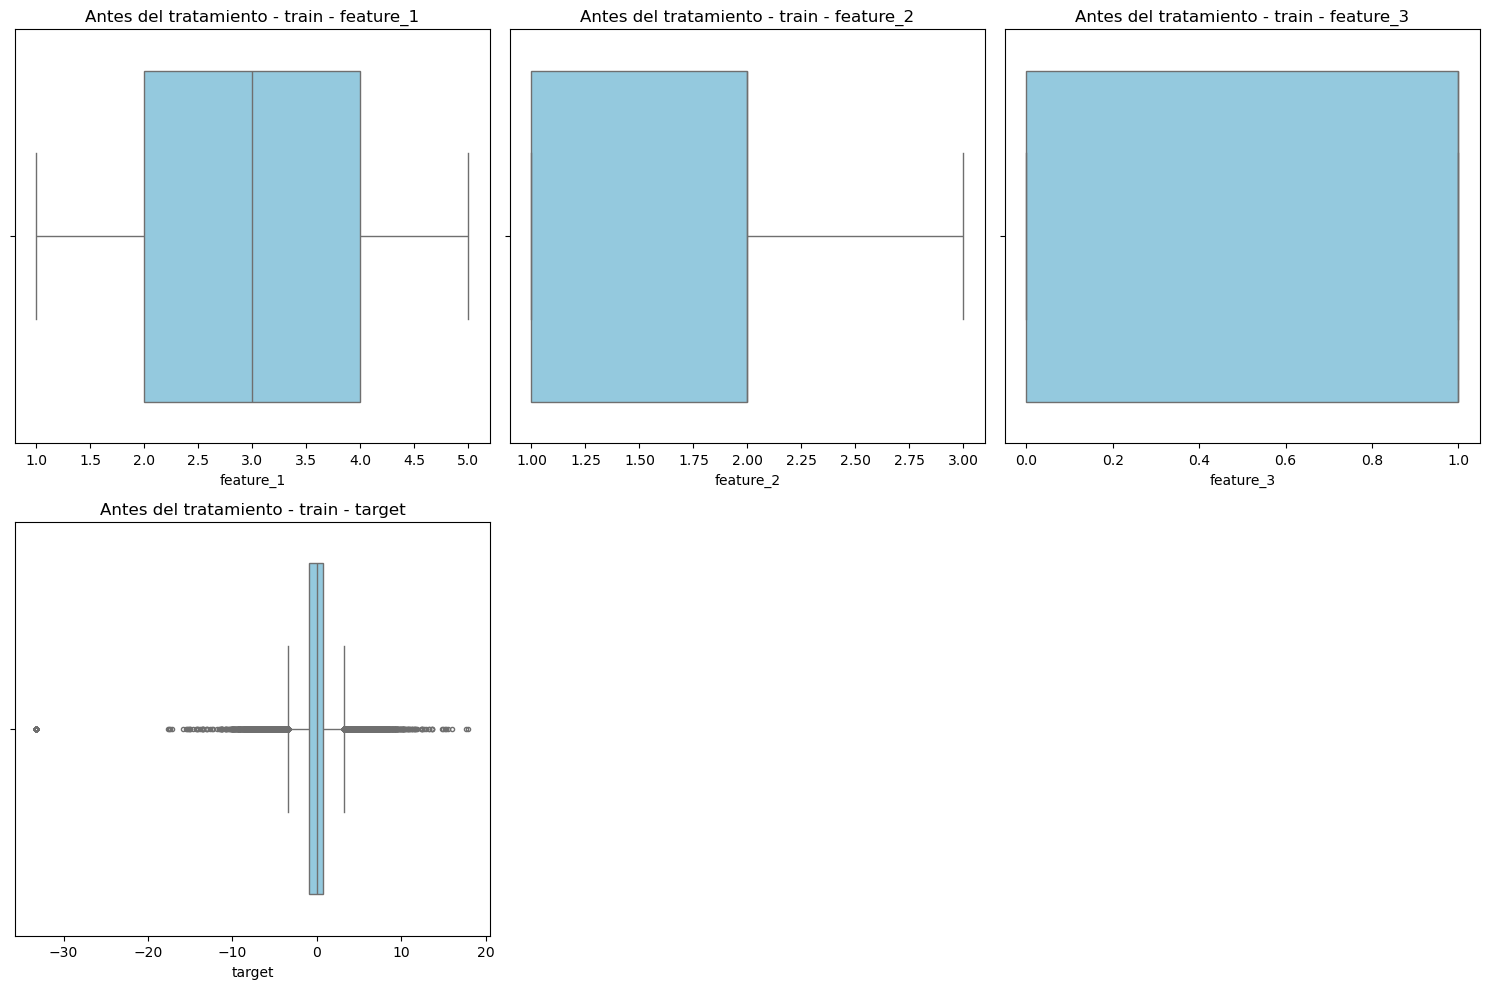

In [54]:
graficar_boxplots(train_selected, columnas_train, "Antes del tratamiento - train")



In [62]:
def detectar_outliers(df, columnas):
    outliers = {}
    for col in columnas:
        if pd.api.types.is_numeric_dtype(df[col]):
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            limite_inferior = Q1 - 1.5 * IQR
            limite_superior = Q3 + 1.5 * IQR
            outlier_mask = (df[col] < limite_inferior) | (df[col] > limite_superior)
            total_outliers = outlier_mask.sum()
            if total_outliers > 0:
                outliers[col] = total_outliers
    return outliers


In [64]:
print(detectar_outliers(train_selected, columnas_train))
print(detectar_outliers(historical_selected, columnas_hist))
print(detectar_outliers(new_merchant_selected, columnas_hist))
print(detectar_outliers(merchants_selected, columnas_merchant))


{'target': np.int64(15397)}
{'purchase_amount': np.int64(2907482), 'installments': np.int64(1178517)}
{'purchase_amount': np.int64(200708), 'installments': np.int64(93958)}
{'avg_sales_lag3': np.int64(36638), 'avg_sales_lag6': np.int64(36260), 'avg_sales_lag12': np.int64(35822), 'avg_purchases_lag3': np.int64(37533), 'avg_purchases_lag6': np.int64(36444), 'avg_purchases_lag12': np.int64(35721)}


In [66]:
def tratar_outliers(df, columnas, metodo="mediana"):
    for col in columnas:
        if pd.api.types.is_numeric_dtype(df[col]):
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            limite_inferior = Q1 - 1.5 * IQR
            limite_superior = Q3 + 1.5 * IQR

            if metodo == "mediana":
                valor_reemplazo = df[col].median()
            elif metodo == "media":
                valor_reemplazo = df[col].mean()
            else:
                continue  
            df.loc[df[col] < limite_inferior, col] = valor_reemplazo
            df.loc[df[col] > limite_superior, col] = valor_reemplazo


In [68]:
tratar_outliers(train_selected, columnas_train, metodo="mediana")
tratar_outliers(historical_selected, columnas_hist, metodo="mediana")
tratar_outliers(new_merchant_selected, columnas_hist, metodo="mediana")
tratar_outliers(merchants_selected, columnas_merchant, metodo="mediana")


In [70]:
print(detectar_outliers(train_selected, columnas_train))
print(detectar_outliers(historical_selected, columnas_hist))
print(detectar_outliers(new_merchant_selected, columnas_hist))
print(detectar_outliers(merchants_selected, columnas_merchant))

{'target': np.int64(8705)}
{'purchase_amount': np.int64(2462362)}
{'purchase_amount': np.int64(140314)}
{'avg_sales_lag3': np.int64(25845), 'avg_sales_lag6': np.int64(19927), 'avg_sales_lag12': np.int64(22006), 'avg_purchases_lag3': np.int64(24397), 'avg_purchases_lag6': np.int64(22985), 'avg_purchases_lag12': np.int64(21105)}


## Corrección de valores erróneos, inconsistentes o duplicados.

In [72]:
def mostrar_duplicados(df, nombre_df="DataFrame"):
    duplicados = df[df.duplicated()]
    n = len(duplicados)
    print(f"{nombre_df} tiene {n} filas duplicadas.")
    if n > 0:
        display(duplicados.head(10))


In [74]:
mostrar_duplicados(train_selected, "train_selected")
mostrar_duplicados(historical_selected, "historical_selected")
mostrar_duplicados(new_merchant_selected, "new_merchant_selected")
mostrar_duplicados(merchants_selected, "merchants_selected")

train_selected tiene 0 filas duplicadas.
historical_selected tiene 37353 filas duplicadas.


,card_id,purchase_date,purchase_amount,installments,month_lag,category_1,category_2,category_3,merchant_id,state_id,city_id
4165,C_ID_b45d4d37b1,2017-12-15 14:16:49,-0.728876,1,-2,N,5.0,B,M_ID_b0feef5844,21,120
6576,C_ID_ad99f08d4c,2017-02-18 11:00:21,-0.688349,2,-12,N,1.0,C,M_ID_0ecf00e563,9,265
8478,C_ID_9e6b3e491a,2017-11-30 00:00:00,-0.706336,0,-3,N,3.0,A,M_ID_6dc4ef819f,2,244
9235,C_ID_23518d5fe7,2017-11-11 00:00:00,-0.585914,0,-3,N,1.0,A,M_ID_2637773dd2,9,69
9756,C_ID_3df86e0089,2017-10-09 15:57:33,-0.688349,1,-4,Y,Unknown,B,M_ID_9139332ccc,-1,-1
11006,C_ID_aa76adb703,2017-11-19 00:00:00,-0.688349,0,-3,N,Unknown,A,M_ID_cfa52d2ea7,-1,-1
11296,C_ID_9deaeaf200,2017-12-07 23:04:49,-0.724368,0,-1,N,1.0,A,M_ID_50f575c681,9,69
12308,C_ID_bdf550bccd,2017-11-28 14:18:48,-0.725871,1,-3,N,1.0,B,M_ID_50f575c681,9,69
12597,C_ID_6107f3d6c2,2017-04-24 20:20:07,-0.480247,0,-10,N,1.0,A,M_ID_1d574aaed2,9,314
12723,C_ID_5b28e30255,2017-11-20 00:00:00,-0.544050,0,-3,N,4.0,A,M_ID_e5517e40fa,4,212


new_merchant_selected tiene 38 filas duplicadas.


,card_id,purchase_date,purchase_amount,installments,month_lag,category_1,category_2,category_3,merchant_id,state_id,city_id
2180,C_ID_8222fde29c,2017-11-25 00:00:00,-0.674841,1,2,N,5.0,B,M_ID_7c02abc1a8,5,143
26003,C_ID_6c40424ee1,2018-03-26 16:03:15,-0.674841,1,1,N,5.0,C,M_ID_a87d7378ac,21,333
47118,C_ID_63c8bf7aa3,2017-08-27 13:26:18,-0.674841,1,1,Y,Unknown,C,M_ID_9139332ccc,-1,-1
73148,C_ID_8cce90e147,2018-04-20 16:32:56,-0.674841,1,2,Y,Unknown,C,M_ID_a87d7378ac,-1,-1
124189,C_ID_340d462d08,2017-11-27 00:00:00,-0.674841,-1,2,N,3.0,Unknown,M_ID_e869fb25e6,1,292
124195,C_ID_340d462d08,2017-11-27 00:00:00,-0.674841,-1,2,N,3.0,Unknown,M_ID_29973526c5,1,292
124202,C_ID_340d462d08,2017-11-24 00:00:00,-0.674841,-1,2,N,3.0,Unknown,M_ID_bdc1984a9b,11,87
184127,C_ID_98a7d50899,2018-03-23 23:46:23,-0.674841,1,1,Y,Unknown,C,M_ID_9139332ccc,-1,-1
184391,C_ID_a957743c02,2017-11-24 00:00:00,-0.674841,-1,1,N,3.0,Unknown,M_ID_7c7d314035,1,246
252268,C_ID_fdf47fda44,2018-03-29 16:44:20,-0.674841,1,2,N,5.0,C,M_ID_a87d7378ac,21,333


merchants_selected tiene 0 filas duplicadas.


In [80]:
def eliminar_duplicados(df, nombre_df="DataFrame"):
    duplicados = df.duplicated().sum()
    if duplicados > 0:
        print(f"{nombre_df}: {duplicados} filas duplicadas eliminadas.")
        df_sin_duplicados = df.drop_duplicates()
        return df_sin_duplicados
    else:
        print(f"{nombre_df}: No se encontraron filas duplicadas.")
        return df



In [82]:
eliminar_duplicados(train_selected, "train_selected")
eliminar_duplicados(historical_selected, "historical_selected")
eliminar_duplicados(new_merchant_selected, "new_merchant_selected")
eliminar_duplicados(merchants_selected, "merchants_selected")


train_selected: No se encontraron filas duplicadas.
historical_selected: No se encontraron filas duplicadas.
new_merchant_selected: No se encontraron filas duplicadas.
merchants_selected: No se encontraron filas duplicadas.


,merchant_id,merchant_group_id,category_1,category_2,avg_sales_lag3,avg_sales_lag6,avg_sales_lag12,avg_purchases_lag3,avg_purchases_lag6,avg_purchases_lag12,most_recent_sales_range,most_recent_purchases_range,category_4,city_id,state_id
0,M_ID_838061e48c,8353,N,1.0,1.00,1.01,1.02,1.016667,1.026961,1.043361,E,E,N,242,9
1,M_ID_9339d880ad,3184,N,1.0,1.00,1.01,1.02,1.016667,1.291667,1.687500,E,E,N,22,16
2,M_ID_e726bbae1e,447,N,5.0,1.00,1.01,1.02,1.016667,1.026961,1.043361,E,E,N,-1,5
3,M_ID_a70e9c5f81,5026,Y,Unknown,1.00,1.01,1.02,1.016667,1.026961,1.043361,E,E,Y,-1,-1
4,M_ID_64456c37ce,2228,Y,Unknown,1.00,1.01,1.02,1.016667,1.026961,0.347222,E,E,Y,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334691,M_ID_1f4773aa76,1145,N,1.0,1.00,0.99,1.00,1.022618,1.019505,1.024796,A,A,Y,69,9
334692,M_ID_725a60d404,35,Y,Unknown,0.89,0.78,0.59,0.927684,0.813473,0.606765,A,A,Y,-1,-1
334693,M_ID_f2045dd267,35,N,5.0,0.96,0.90,0.74,0.982957,0.924769,0.750763,A,A,Y,160,21
334694,M_ID_9139332ccc,35,Y,Unknown,0.94,0.82,0.65,0.919558,0.783000,0.584000,A,A,Y,-1,-1


In [84]:
def mostrar_negativos(df, columnas, nombre_df="DataFrame"):
    for col in columnas:
        if col in df.columns:
            negativos = df[df[col] < 0]
            n = len(negativos)
            print(f"{nombre_df} - '{col}' tiene {n} valores negativos.")
            if n > 0:
                display(negativos.head(10))


In [86]:
columnas_num_historical = ["purchase_amount", "installments"]
columnas_num_new_merchant = ["purchase_amount", "installments"]

mostrar_negativos(historical_selected, columnas_num_historical, "historical_selected")
mostrar_negativos(new_merchant_selected, columnas_num_new_merchant, "new_merchant_selected")

historical_selected - 'purchase_amount' tiene 29075008 valores negativos.


,card_id,purchase_date,purchase_amount,installments,month_lag,category_1,category_2,category_3,merchant_id,state_id,city_id
0,C_ID_4e6213e9bc,2017-06-25 15:33:07,-0.703331,0,-8,N,1.0,A,M_ID_e020e9b302,16,88
1,C_ID_4e6213e9bc,2017-07-15 12:10:45,-0.733128,0,-7,N,1.0,A,M_ID_86ec983688,16,88
2,C_ID_4e6213e9bc,2017-08-09 22:04:29,-0.720386,0,-6,N,1.0,A,M_ID_979ed661fc,16,88
3,C_ID_4e6213e9bc,2017-09-02 10:06:26,-0.735352,0,-5,N,1.0,A,M_ID_e6d5ae8ea6,16,88
4,C_ID_4e6213e9bc,2017-03-10 01:14:19,-0.722865,0,-11,N,1.0,A,M_ID_e020e9b302,16,88
5,C_ID_4e6213e9bc,2018-02-24 08:45:05,-0.734887,0,0,N,1.0,A,M_ID_50af771f8d,9,333
6,C_ID_4e6213e9bc,2017-03-21 00:10:51,-0.716855,0,-11,N,1.0,A,M_ID_5e8220e564,16,88
7,C_ID_4e6213e9bc,2017-11-18 20:05:55,-0.657049,0,-3,N,1.0,A,M_ID_9d41786a50,16,3
8,C_ID_4e6213e9bc,2017-06-01 22:02:56,-0.737967,0,-8,N,1.0,A,M_ID_979ed661fc,16,88
9,C_ID_4e6213e9bc,2017-03-16 15:41:22,-0.715352,0,-11,N,1.0,A,M_ID_74ba14b5fc,16,88


historical_selected - 'installments' tiene 176729 valores negativos.


,card_id,purchase_date,purchase_amount,installments,month_lag,category_1,category_2,category_3,merchant_id,state_id,city_id
885,C_ID_fc8e41b9cf,2018-01-23 12:05:13,-0.688349,-1,-1,N,3.0,Unknown,M_ID_c4f5972059,8,251
914,C_ID_fc8e41b9cf,2018-02-21 07:24:59,-0.688349,-1,0,N,3.0,Unknown,M_ID_bc5663de31,8,251
936,C_ID_fc8e41b9cf,2017-11-13 00:00:00,-0.475694,-1,-3,N,3.0,Unknown,M_ID_0f437c5559,8,251
941,C_ID_fc8e41b9cf,2018-01-09 14:15:12,-0.551563,-1,-1,N,3.0,Unknown,M_ID_b7441bb10f,8,170
965,C_ID_fc8e41b9cf,2018-01-23 14:04:39,-0.688349,-1,-1,N,3.0,Unknown,M_ID_1dd8347bcb,8,251
992,C_ID_fc8e41b9cf,2017-11-27 00:00:00,-0.688349,-1,-3,N,3.0,Unknown,M_ID_d12eaa9bd7,8,251
1003,C_ID_fc8e41b9cf,2017-12-05 11:32:24,-0.538791,-1,-2,N,3.0,Unknown,M_ID_b39aa08d22,8,251
1031,C_ID_fc8e41b9cf,2018-01-06 10:40:46,-0.611669,-1,-1,N,3.0,Unknown,M_ID_944c5bc932,8,170
1035,C_ID_fc8e41b9cf,2017-12-06 10:58:34,-0.521510,-1,-2,N,3.0,Unknown,M_ID_4838a2855e,8,170
2329,C_ID_058b254a5b,2017-12-16 10:06:39,-0.581616,-1,-2,N,1.0,Unknown,M_ID_a225855c6f,9,233


new_merchant_selected - 'purchase_amount' tiene 1962993 valores negativos.


,card_id,purchase_date,purchase_amount,installments,month_lag,category_1,category_2,category_3,merchant_id,state_id,city_id
0,C_ID_415bb3a509,2018-03-11 14:57:36,-0.557574,1,1,N,1.0,B,M_ID_b0c793002c,9,107
1,C_ID_415bb3a509,2018-03-19 18:53:37,-0.569580,1,1,N,1.0,B,M_ID_88920c89e8,9,140
2,C_ID_415bb3a509,2018-04-26 14:08:44,-0.551037,1,2,N,1.0,B,M_ID_ad5237ef6b,9,330
3,C_ID_415bb3a509,2018-03-07 09:43:21,-0.671925,1,1,Y,Unknown,B,M_ID_9e84cda3b1,-1,-1
4,C_ID_ef55cf8d4b,2018-03-22 21:07:53,-0.659904,1,1,Y,Unknown,B,M_ID_3c86fa3831,-1,-1
5,C_ID_ef55cf8d4b,2018-04-02 12:53:28,-0.633007,1,2,N,1.0,B,M_ID_8874615e00,9,231
6,C_ID_ef55cf8d4b,2018-03-28 19:50:19,-0.674841,1,1,N,1.0,B,M_ID_6d061b5ddc,9,69
7,C_ID_ef55cf8d4b,2018-04-05 08:06:52,-0.553787,1,2,N,1.0,B,M_ID_df1e022f41,9,231
8,C_ID_ef55cf8d4b,2018-04-07 18:37:40,-0.596643,1,2,N,1.0,B,M_ID_d15eae0468,9,69
9,C_ID_ef55cf8d4b,2018-03-17 18:10:41,-0.607191,1,1,N,1.0,B,M_ID_5f9bffd028,9,69


new_merchant_selected - 'installments' tiene 55914 valores negativos.


,card_id,purchase_date,purchase_amount,installments,month_lag,category_1,category_2,category_3,merchant_id,state_id,city_id
10,C_ID_ef55cf8d4b,2018-03-31 09:55:40,-0.674841,-1,1,N,1.0,Unknown,M_ID_3ffd43b4cd,9,69
189,C_ID_fd55871fd8,2018-02-10 09:33:55,-0.674841,-1,1,N,1.0,Unknown,M_ID_2a7d376053,15,187
270,C_ID_6bf003900f,2018-03-02 18:00:10,-0.596673,-1,1,N,1.0,Unknown,M_ID_1b3e5a9b05,9,69
306,C_ID_e4d60467c2,2018-03-22 13:49:08,-0.596643,-1,1,N,1.0,Unknown,M_ID_2da56d089d,9,69
402,C_ID_cb2269c52d,2018-04-26 14:36:11,-0.416325,-1,2,N,1.0,Unknown,M_ID_6972fc7624,9,213
410,C_ID_cb2269c52d,2018-03-09 14:26:28,-0.410524,-1,1,N,1.0,Unknown,M_ID_59f6ac5d37,9,213
447,C_ID_b25d492593,2018-04-13 12:01:02,-0.686802,-1,2,N,1.0,Unknown,M_ID_9b6a46e720,16,308
448,C_ID_b25d492593,2018-04-21 07:29:12,-0.536537,-1,2,N,1.0,Unknown,M_ID_81dcc31929,16,308
468,C_ID_2bba08c2c4,2018-04-20 08:34:02,-0.611804,-1,2,N,4.0,Unknown,M_ID_f95f2434d4,4,107
641,C_ID_c5bf64ecbd,2018-03-10 08:12:11,-0.674841,-1,1,N,1.0,Unknown,M_ID_3dfd6d6de7,9,19


## Normalización de formatos (ej: fechas, strings, booleans).

In [100]:
def normalizar_formatos(df):
    for col in df.columns:
        if "date" in col.lower() or "month" in col.lower() or "fecha" in col.lower():
            try:
                df.loc[:, col] = pd.to_datetime(df[col], errors='coerce')  # convierte o pone NaT si no puede
                print(f"Columna '{col}' convertida a datetime")
            except Exception as e:
                print(f"No se pudo convertir '{col}' a datetime: {e}")

    for col in df.select_dtypes(include=["object"]).columns:
        try:
            df.loc[:, col] = df[col].astype(str).str.strip().str.lower()
            print(f"Columna '{col}' normalizada (strip + lower)")
        except Exception as e:
            print(f"No se pudo normalizar '{col}': {e}")
            
    for col in df.select_dtypes(include=["int64", "float64"]).columns:
        try:
            if pd.api.types.is_float_dtype(df[col]):
                df.loc[:, col] = df[col].astype(float)
            else:
                df.loc[:, col] = df[col].astype(int)
            print(f"Columna '{col}' convertida a tipo numérico")
        except Exception as e:
            print(f"No se pudo convertir '{col}' a tipo numérico: {e}")

    return df


In [102]:
train_selected = normalizar_formatos(train_selected)
historical_selected = normalizar_formatos(historical_selected)
new_merchant_selected = normalizar_formatos(new_merchant_selected)
merchants_selected = normalizar_formatos(merchants_selected)


Columna 'first_active_month' convertida a datetime
Columna 'card_id' normalizada (strip + lower)
Columna 'feature_1' convertida a tipo numérico
Columna 'feature_2' convertida a tipo numérico
Columna 'feature_3' convertida a tipo numérico
Columna 'target' convertida a tipo numérico
Columna 'purchase_date' convertida a datetime
Columna 'month_lag' convertida a datetime
Columna 'card_id' normalizada (strip + lower)
Columna 'category_1' normalizada (strip + lower)
Columna 'category_2' normalizada (strip + lower)
Columna 'category_3' normalizada (strip + lower)
Columna 'merchant_id' normalizada (strip + lower)
Columna 'purchase_amount' convertida a tipo numérico
Columna 'installments' convertida a tipo numérico
Columna 'state_id' convertida a tipo numérico
Columna 'city_id' convertida a tipo numérico
Columna 'purchase_date' convertida a datetime
Columna 'month_lag' convertida a datetime
Columna 'card_id' normalizada (strip + lower)
Columna 'category_1' normalizada (strip + lower)
Columna 'c

# 4. Integración de Datos

## Uniones entre tablas (por ejemplo: train + transacciones + merchants).

In [17]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
# leer con polars los dataframes finales
train_selected = pl.read_csv("src/final_data/train_selected.csv", try_parse_dates=True)
transaction = pl.read_csv("src/final_data/transaction.csv", try_parse_dates=True)
merchants_selected = pl.read_csv("src/final_data/merchants_selected.csv")

In [2]:
train_selected

card_id,first_active_month,feature_1,feature_2,target
str,str,i64,i64,f64
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338
"""C_ID_581b5c0a61""","""2017-09""",1,1,-3.142942
"""C_ID_fbf828d6ef""","""2017-08""",3,1,0.879763
"""C_ID_b909e94f81""","""2017-10""",3,1,-0.204948
"""C_ID_c586c8629c""","""2017-04""",4,2,-1.869343
…,…,…,…,…
"""C_ID_d0208eb48c""","""2017-11""",5,1,-0.094717
"""C_ID_f065bb3ce7""","""2017-01""",5,1,-0.192
"""C_ID_bd81d3768e""","""2017-05""",2,1,0.926547


In [18]:
# unir los dataframes de train_selected y transaction. La unión se hace por la columna card_id
def unir_dataframes(df1, df2, clave):
    df_unido = df1.join(df2, on=clave, how="left")
    return df_unido
train_transaction = unir_dataframes(train_selected, transaction, "card_id")
#train_transaction = train_transaction.drop_nulls(subset=["purchase_date", "merchant_id"])

# contabilizar las columnas de train_transaction que tengan valores nulos
nulos_train_transaction = train_transaction.null_count().to_dict(as_series=False)
nulos_train_transaction

{'card_id': [0],
 'first_active_month': [0],
 'feature_1': [0],
 'feature_2': [0],
 'target': [0],
 'purchase_date': [27389],
 'authorized_flag': [27389],
 'installments': [27389],
 'merchant_category_id': [27389],
 'merchant_id': [27389],
 'purchase_amount': [27389]}

In [21]:
# eliminar las filas que tengan valores nulos en las columnas merchant_id
train_transaction = train_transaction.filter(pl.col("merchant_id").is_not_null())


nulos_t_t = train_transaction.null_count().to_dict(as_series=False)
nulos_t_t


{'card_id': [0],
 'first_active_month': [0],
 'feature_1': [0],
 'feature_2': [0],
 'target': [0],
 'purchase_date': [0],
 'authorized_flag': [0],
 'installments': [0],
 'merchant_category_id': [0],
 'merchant_id': [0],
 'purchase_amount': [0]}

In [22]:
# unir los dataframes de train_transaction y merchants_selected. La unión se hace por la columna merchant_id
def unir_dataframes_merchants(df1, df2, clave):
    df_unido = df1.join(df2, on=clave, how="left")
    return df_unido
train_transaction_merchants = unir_dataframes_merchants(train_transaction, merchants_selected, "merchant_id")

# contabilizar las columnas de train_transaction_merchants que tengan valores nulos
nulos_train_transaction_merchants = train_transaction_merchants.null_count().to_dict(as_series=False)
nulos_train_transaction_merchants


{'card_id': [0],
 'first_active_month': [0],
 'feature_1': [0],
 'feature_2': [0],
 'target': [0],
 'purchase_date': [0],
 'authorized_flag': [0],
 'installments': [0],
 'merchant_category_id': [0],
 'merchant_id': [0],
 'purchase_amount': [0],
 'merchant_group_id': [0],
 'merchant_category_id_right': [0],
 'most_recent_sales_range': [0],
 'most_recent_purchases_range': [0],
 'active_months_lag12': [0]}

## Manejo de duplicados y verificación de cardinalidades.

In [24]:
print(identificar_duplicados(train_transaction_merchants))

shape: (0, 17)
┌─────────┬─────────────┬───────────┬───────────┬───┬────────────┬────────────┬────────────┬───────┐
│ card_id ┆ first_activ ┆ feature_1 ┆ feature_2 ┆ … ┆ most_recen ┆ most_recen ┆ active_mon ┆ count │
│ ---     ┆ e_month     ┆ ---       ┆ ---       ┆   ┆ t_sales_ra ┆ t_purchase ┆ ths_lag12  ┆ ---   │
│ str     ┆ ---         ┆ i64       ┆ i64       ┆   ┆ nge        ┆ s_range    ┆ ---        ┆ u32   │
│         ┆ str         ┆           ┆           ┆   ┆ ---        ┆ ---        ┆ i64        ┆       │
│         ┆             ┆           ┆           ┆   ┆ str        ┆ str        ┆            ┆       │
╞═════════╪═════════════╪═══════════╪═══════════╪═══╪════════════╪════════════╪════════════╪═══════╡
└─────────┴─────────────┴───────────┴───────────┴───┴────────────┴────────────┴────────────┴───────┘


In [27]:
# Guardar los dataframes filtrados
train_transaction_merchants.write_csv("src/integracion_data/train_transaction_merchants.csv")
train_transaction_merchants

card_id,first_active_month,feature_1,feature_2,target,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount,merchant_group_id,merchant_category_id_right,most_recent_sales_range,most_recent_purchases_range,active_months_lag12
str,str,i64,i64,f64,datetime[μs],str,i64,i64,str,f64,i64,i64,str,str,i64
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""A""","""A""",12
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""E""","""E""",7
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 12:17:59,"""Y""",0,108,"""M_ID_1b20a130f3""",-0.71989,18252,108,"""C""","""C""",12
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""A""","""A""",12
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""E""","""E""",7
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2018-02-17 16:33:30,"""Y""",0,506,"""M_ID_22dba0c2d5""",-0.716269,40476,506,"""C""","""C""",12
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-12-19 12:57:40,"""Y""",0,884,"""M_ID_22dba0c2d5""",-0.641722,40476,506,"""C""","""C""",12
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-11-03 14:23:34,"""Y""",0,80,"""M_ID_5ba019a379""",-0.680791,35,80,"""A""","""A""",12


# 5. Construcción de Variables

In [1]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
# cargar los datos integrados
train_transaction_merchants = pl.read_csv("src/integracion_data/train_transaction_merchants.csv", try_parse_dates=True)
train_transaction_merchants

card_id,first_active_month,feature_1,feature_2,target,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount,merchant_group_id,merchant_category_id_right,most_recent_sales_range,most_recent_purchases_range,active_months_lag12
str,str,i64,i64,f64,datetime[μs],str,i64,i64,str,f64,i64,i64,str,str,i64
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""A""","""A""",12
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""E""","""E""",7
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 12:17:59,"""Y""",0,108,"""M_ID_1b20a130f3""",-0.71989,18252,108,"""C""","""C""",12
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""A""","""A""",12
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""E""","""E""",7
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2018-02-17 16:33:30,"""Y""",0,506,"""M_ID_22dba0c2d5""",-0.716269,40476,506,"""C""","""C""",12
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-12-19 12:57:40,"""Y""",0,884,"""M_ID_22dba0c2d5""",-0.641722,40476,506,"""C""","""C""",12
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-11-03 14:23:34,"""Y""",0,80,"""M_ID_5ba019a379""",-0.680791,35,80,"""A""","""A""",12


In [2]:
train_transaction_merchants = train_transaction_merchants.with_columns(
    pl.when(pl.col("most_recent_sales_range") == "A").then(5)
    .when(pl.col("most_recent_sales_range") == "B").then(4)
    .when(pl.col("most_recent_sales_range") == "C").then(3)
    .when(pl.col("most_recent_sales_range") == "D").then(2)
    .when(pl.col("most_recent_sales_range") == "E").then(1)
    .otherwise(0).alias("sales_range_score"),
    
    pl.when(pl.col("most_recent_purchases_range") == "A").then(5)
    .when(pl.col("most_recent_purchases_range") == "B").then(4)
    .when(pl.col("most_recent_purchases_range") == "C").then(3)
    .when(pl.col("most_recent_purchases_range") == "D").then(2)
    .when(pl.col("most_recent_purchases_range") == "E").then(1)
    .otherwise(0).alias("purchases_range_score")
)

In [3]:
train_transaction_merchants = train_transaction_merchants.with_columns(
    (pl.col("sales_range_score") + pl.col("purchases_range_score")).alias("promotion_score")
)
train_transaction_merchants

card_id,first_active_month,feature_1,feature_2,target,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount,merchant_group_id,merchant_category_id_right,most_recent_sales_range,most_recent_purchases_range,active_months_lag12,sales_range_score,purchases_range_score,promotion_score
str,str,i64,i64,f64,datetime[μs],str,i64,i64,str,f64,i64,i64,str,str,i64,i32,i32,i32
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""A""","""A""",12,5,5,10
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""E""","""E""",7,1,1,2
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 12:17:59,"""Y""",0,108,"""M_ID_1b20a130f3""",-0.71989,18252,108,"""C""","""C""",12,3,3,6
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""A""","""A""",12,5,5,10
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""E""","""E""",7,1,1,2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2018-02-17 16:33:30,"""Y""",0,506,"""M_ID_22dba0c2d5""",-0.716269,40476,506,"""C""","""C""",12,3,3,6
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-12-19 12:57:40,"""Y""",0,884,"""M_ID_22dba0c2d5""",-0.641722,40476,506,"""C""","""C""",12,3,3,6
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-11-03 14:23:34,"""Y""",0,80,"""M_ID_5ba019a379""",-0.680791,35,80,"""A""","""A""",12,5,5,10


In [4]:
train_transaction_merchants_trends = (
    train_transaction_merchants
    .with_columns(
        pl.col("purchase_date").cast(pl.Int64).alias("purchase_date_num"),
        # Crear columnas binarias para authorized_flag
        pl.when(pl.col("authorized_flag") == "Y").then(1).otherwise(0).alias("is_authorized"),
        pl.when(pl.col("authorized_flag") == "N").then(1).otherwise(0).alias("is_not_authorized")
    )
    .group_by("card_id")
    .agg([
        # Métrica de promoción
        pl.col("promotion_score").mean().alias("avg_promotion_score"),
        pl.col("promotion_score").sum().alias("total_promotion_score"),

        # Métricas generales
        pl.count().alias("transaction_count"),
        pl.sum("purchase_amount").alias("total_amount"),
        pl.mean("purchase_amount").alias("mean_amount"),
        pl.median("purchase_amount").alias("median_amount"),
        pl.std("purchase_amount").alias("std_amount"),
        pl.min("purchase_date").alias("first_purchase_date"),
        pl.max("purchase_date").alias("last_purchase_date"),
        (pl.max("purchase_amount") - pl.min("purchase_amount")).alias("amount_range"),
        
        # Diversidad de comerciantes
        pl.col("merchant_id").n_unique().alias("unique_merchants"),
        pl.col("merchant_category_id").n_unique().alias("unique_merchant_categories"),
        pl.col("merchant_group_id").n_unique().alias("unique_merchant_groups"),
        
        # Actividad del comerciante
        # pl.col("active_months_lag3").mean().alias("avg_active_months_lag3"),
        # pl.col("active_months_lag6").mean().alias("avg_active_months_lag6"),
        pl.col("active_months_lag12").mean().alias("avg_active_months_lag12"),
        
        # Métricas autorizadas y no autorizadas
        (pl.col("purchase_amount") * pl.col("is_authorized")).sum().alias("total_amount_authorized"),
        (pl.col("purchase_amount") * pl.col("is_not_authorized")).sum().alias("total_amount_not_authorized"),
        (pl.col("installments") * pl.col("is_authorized")).mean().alias("mean_installments_authorized"),
        (pl.col("installments") * pl.col("is_not_authorized")).mean().alias("mean_installments_not_authorized"),
        
        # Tendencias
        (
            (pl.max("purchase_amount") - pl.min("purchase_amount"))
            / (pl.max("purchase_date_num") - pl.min("purchase_date_num"))
        ).alias("purchase_amount_trend_per_merchant"),
        (
            (pl.max("installments") - pl.min("installments"))
            / (pl.max("purchase_date_num") - pl.min("purchase_date_num"))
        ).alias("installments_trend_per_merchant"),
    ])
)

In [5]:
train_transaction_merchants_trends

card_id,avg_promotion_score,total_promotion_score,transaction_count,total_amount,mean_amount,median_amount,std_amount,first_purchase_date,last_purchase_date,amount_range,unique_merchants,unique_merchant_categories,unique_merchant_groups,avg_active_months_lag12,total_amount_authorized,total_amount_not_authorized,mean_installments_authorized,mean_installments_not_authorized,purchase_amount_trend_per_merchant,installments_trend_per_merchant
str,f64,i32,u32,f64,f64,f64,f64,datetime[μs],datetime[μs],f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64
"""C_ID_717d5400b3""",10.0,370,37,-26.198408,-0.708065,-0.71696,0.021981,2017-11-07 20:50:49,2018-02-27 23:52:26,0.097357,1,1,1,12.0,-26.198408,-0.0,1.0,0.0,1.0050e-14,0.0
"""C_ID_a16ff3d73c""",5.654545,311,55,-33.357549,-0.606501,-0.668785,0.229425,2017-11-06 13:36:15,2018-02-28 21:03:50,1.510796,38,21,25,11.563636,-33.357549,0.0,1.254545,0.0,1.5297e-13,1.1138e-12
"""C_ID_16b7f16697""",6.456522,297,46,-31.162206,-0.677439,-0.709342,0.067979,2017-11-11 00:00:00,2018-02-12 17:06:40,0.293017,26,18,17,11.23913,-31.162206,-0.0,1.0,0.0,3.6189e-14,0.0
"""C_ID_9ce31cc27e""",8.333333,50,6,-2.746155,-0.457693,-0.558859,0.350904,2017-11-07 14:41:05,2018-02-06 17:50:10,0.959969,4,4,3,12.0,-2.746155,0.0,0.0,0.0,1.2192e-13,0.0
"""C_ID_03a25b0bb2""",7.076923,184,26,-16.62963,-0.639601,-0.656749,0.075515,2017-11-04 23:06:33,2018-02-09 12:40:22,0.317961,10,7,6,10.961538,-8.916552,-7.713078,0.730769,0.807692,3.8110e-14,7.1915e-13
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_d6c252ccae""",9.75,39,4,-2.810318,-0.70258,-0.716855,0.037082,2017-11-04 00:50:28,2017-11-25 20:35:31,0.081143,3,3,2,12.0,-2.081442,-0.728876,0.0,0.0,4.3035e-14,0.0
"""C_ID_d4d941a288""",6.359551,566,89,-54.777736,-0.61548,-0.676283,0.173229,2017-11-02 18:58:50,2018-02-28 15:47:57,0.801679,29,16,20,11.101124,-54.338602,-0.439135,1.258427,0.235955,7.8721e-14,9.8196e-13
"""C_ID_b4cf6216b4""",6.88,172,25,-15.115769,-0.604631,-0.663105,0.126207,2017-11-07 16:28:43,2018-01-31 21:49:56,0.34277,20,12,14,11.96,-13.725877,-1.389892,0.0,0.0,4.6551e-14,0.0


In [6]:
train_transaction_merchants

card_id,first_active_month,feature_1,feature_2,target,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount,merchant_group_id,merchant_category_id_right,most_recent_sales_range,most_recent_purchases_range,active_months_lag12,sales_range_score,purchases_range_score,promotion_score
str,str,i64,i64,f64,datetime[μs],str,i64,i64,str,f64,i64,i64,str,str,i64,i32,i32,i32
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""A""","""A""",12,5,5,10
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""E""","""E""",7,1,1,2
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 12:17:59,"""Y""",0,108,"""M_ID_1b20a130f3""",-0.71989,18252,108,"""C""","""C""",12,3,3,6
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""A""","""A""",12,5,5,10
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""E""","""E""",7,1,1,2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2018-02-17 16:33:30,"""Y""",0,506,"""M_ID_22dba0c2d5""",-0.716269,40476,506,"""C""","""C""",12,3,3,6
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-12-19 12:57:40,"""Y""",0,884,"""M_ID_22dba0c2d5""",-0.641722,40476,506,"""C""","""C""",12,3,3,6
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-11-03 14:23:34,"""Y""",0,80,"""M_ID_5ba019a379""",-0.680791,35,80,"""A""","""A""",12,5,5,10


In [7]:
from datetime import datetime
current_date = datetime.now()
train_transaction_merchants_final_acotado = train_transaction_merchants.join(
    train_transaction_merchants_trends,
    on="card_id",
    how="left"
).with_columns(
    # Antiguedad del cliente desde el first_purchase_date
    (pl.col("last_purchase_date").cast(pl.Int64) - pl.col("first_purchase_date").cast(pl.Int64)).alias("firs_last_purchase_diff"), 
    # Antiguedad del cliente desde el primer mes de actividad
    (pl.col("last_purchase_date").cast(pl.Int64) - pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m").cast(pl.Int64)).alias("first_active_last_purchase_diff"),
    # Antiguedad del cliente desde el primer mes de actividad hasta la fecha actual
    (pl.lit(current_date).cast(pl.Int64) - pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m").cast(pl.Int64)).alias("first_active_to_now_days")
)

In [8]:
train_transaction_merchants_final_acotado.schema

Schema([('card_id', String),
        ('first_active_month', String),
        ('feature_1', Int64),
        ('feature_2', Int64),
        ('target', Float64),
        ('purchase_date', Datetime(time_unit='us', time_zone=None)),
        ('authorized_flag', String),
        ('installments', Int64),
        ('merchant_category_id', Int64),
        ('merchant_id', String),
        ('purchase_amount', Float64),
        ('merchant_group_id', Int64),
        ('merchant_category_id_right', Int64),
        ('most_recent_sales_range', String),
        ('most_recent_purchases_range', String),
        ('active_months_lag12', Int64),
        ('sales_range_score', Int32),
        ('purchases_range_score', Int32),
        ('promotion_score', Int32),
        ('avg_promotion_score', Float64),
        ('total_promotion_score', Int32),
        ('transaction_count', UInt32),
        ('total_amount', Float64),
        ('mean_amount', Float64),
        ('median_amount', Float64),
        ('std_amount', Float

In [9]:
#identificar cantidad de nulos por columna de train_transaction_merchants_final_acotado
nulos_train_transaction_merchants_final_acotado = train_transaction_merchants_final_acotado.null_count().to_dict(as_series=False)
nulos_train_transaction_merchants_final_acotado

{'card_id': [0],
 'first_active_month': [0],
 'feature_1': [0],
 'feature_2': [0],
 'target': [0],
 'purchase_date': [0],
 'authorized_flag': [0],
 'installments': [0],
 'merchant_category_id': [0],
 'merchant_id': [0],
 'purchase_amount': [0],
 'merchant_group_id': [0],
 'merchant_category_id_right': [0],
 'most_recent_sales_range': [0],
 'most_recent_purchases_range': [0],
 'active_months_lag12': [0],
 'sales_range_score': [0],
 'purchases_range_score': [0],
 'promotion_score': [0],
 'avg_promotion_score': [0],
 'total_promotion_score': [0],
 'transaction_count': [0],
 'total_amount': [0],
 'mean_amount': [0],
 'median_amount': [0],
 'std_amount': [2583],
 'first_purchase_date': [0],
 'last_purchase_date': [0],
 'amount_range': [0],
 'unique_merchants': [0],
 'unique_merchant_categories': [0],
 'unique_merchant_groups': [0],
 'avg_active_months_lag12': [0],
 'total_amount_authorized': [0],
 'total_amount_not_authorized': [0],
 'mean_installments_authorized': [0],
 'mean_installments_

In [10]:
train_transaction_merchants_final_acotado

card_id,first_active_month,feature_1,feature_2,target,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount,merchant_group_id,merchant_category_id_right,most_recent_sales_range,most_recent_purchases_range,active_months_lag12,sales_range_score,purchases_range_score,promotion_score,avg_promotion_score,total_promotion_score,transaction_count,total_amount,mean_amount,median_amount,std_amount,first_purchase_date,last_purchase_date,amount_range,unique_merchants,unique_merchant_categories,unique_merchant_groups,avg_active_months_lag12,total_amount_authorized,total_amount_not_authorized,mean_installments_authorized,mean_installments_not_authorized,purchase_amount_trend_per_merchant,installments_trend_per_merchant,firs_last_purchase_diff,first_active_last_purchase_diff,first_active_to_now_days
str,str,i64,i64,f64,datetime[μs],str,i64,i64,str,f64,i64,i64,str,str,i64,i32,i32,i32,f64,i32,u32,f64,f64,f64,f64,datetime[μs],datetime[μs],f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""A""","""A""",12,5,5,10,5.9,59,10,-7.200269,-0.720027,-0.717651,0.013131,2017-11-19 18:58:28,2017-12-03 12:07:52,0.034561,5,3,5,10.5,-7.200269,-0.0,0.0,0.0,2.9166e-14,0.0,1184964000000,1512302871983778,1750267824872479
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""E""","""E""",7,1,1,2,5.9,59,10,-7.200269,-0.720027,-0.717651,0.013131,2017-11-19 18:58:28,2017-12-03 12:07:52,0.034561,5,3,5,10.5,-7.200269,-0.0,0.0,0.0,2.9166e-14,0.0,1184964000000,1512302871983778,1750267824872479
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 12:17:59,"""Y""",0,108,"""M_ID_1b20a130f3""",-0.71989,18252,108,"""C""","""C""",12,3,3,6,5.9,59,10,-7.200269,-0.720027,-0.717651,0.013131,2017-11-19 18:58:28,2017-12-03 12:07:52,0.034561,5,3,5,10.5,-7.200269,-0.0,0.0,0.0,2.9166e-14,0.0,1184964000000,1512302871983778,1750267824872479
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""A""","""A""",12,5,5,10,5.9,59,10,-7.200269,-0.720027,-0.717651,0.013131,2017-11-19 18:58:28,2017-12-03 12:07:52,0.034561,5,3,5,10.5,-7.200269,-0.0,0.0,0.0,2.9166e-14,0.0,1184964000000,1512302871983778,1750267824872479
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""E""","""E""",7,1,1,2,5.9,59,10,-7.200269,-0.720027,-0.717651,0.013131,2017-11-19 18:58:28,2017-12-03 12:07:52,0.034561,5,3,5,10.5,-7.200269,-0.0,0.0,0.0,2.9166e-14,0.0,1184964000000,1512302871983778,1750267824872479
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2018-02-17 16:33:30,"""Y""",0,506,"""M_ID_22dba0c2d5""",-0.716269,40476,506,"""C""","""C""",12,3,3,6,7.375,59,8,-5.362902,-0.670363,-0.676283,0.03572,2017-11-03 14:23:34,2018-02-17 18:24:47,0.102631,7,7,7,12.0,-5.362902,-0.0,0.0,0.0,1.1189e-14,0.0,9172873000000,1518891886983199,1750267824871900
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-12-19 12:57:40,"""Y""",0,884,"""M_ID_22dba0c2d5""",-0.641722,40476,506,"""C""","""C""",12,3,3,6,7.375,59,8,-5.362902,-0.670363,-0.676283,0.03572,2017-11-03 14:23:34,2018-02-17 18:24:47,0.102631,7,7,7,12.0,-5.362902,-0.0,0.0,0.0,1.1189e-14,0.0,9172873000000,1518891886983199,1750267824871900
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-11-03 14:23:34,"""Y""",0,80,"""M_ID_5ba019a379""",-0.680791,35,80,"""A""","""A""",12,5,5,10,7.375,59,8,-5.362902,-0.670363,-0.676283,0.03572,2017-11-03 14:23:34,2018-02-17 18:24:47,0.102631,7,7,7,12.0,-5.362902,-0.0,0.0,0.0,1.1189e-14,0.0,9172873000000,1518891886983199,1750267824871900


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Convertir a pandas para manipulación
df_final = train_transaction_merchants_final_acotado.to_pandas()

# Verificar las columnas numéricas
numeric_cols = [
    'avg_promotion_score', 'total_promotion_score', 'transaction_count', 'total_amount',
    'mean_amount', 'median_amount', 'std_amount', 'amount_range', 'unique_merchants',
    'unique_merchant_categories', 'unique_merchant_groups', 'avg_active_months_lag12', 'total_amount_authorized',
    'total_amount_not_authorized', 'mean_installments_authorized', 'mean_installments_not_authorized',
    'purchase_amount_trend_per_merchant', 'installments_trend_per_merchant',
    'firs_last_purchase_diff', 'first_active_last_purchase_diff', 'first_active_to_now_days'
]

# Asegurarse de que todas las columnas sean numéricas
numeric_cols = [col for col in numeric_cols if pd.api.types.is_numeric_dtype(df_final[col])]

# Aplicar transformaciones logarítmicas a columnas seleccionadas
log_cols = ['total_amount', 'transaction_count', 'total_amount_authorized', 'total_amount_not_authorized']
for col in log_cols:
    if col in df_final.columns:
        df_final[f'log_{col}'] = np.log1p(df_final[col])  # log(1 + x) para evitar log(0)

# Reemplazar valores infinitos por NaN
df_final[numeric_cols] = df_final[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Rellenar valores NaN con la mediana de cada columna
df_final[numeric_cols] = df_final[numeric_cols].fillna(df_final[numeric_cols].median())

# Estandarizar las columnas numéricas
scaler = StandardScaler()
scaled_cols = [f'scaled_{col}' for col in numeric_cols]
df_final[scaled_cols] = scaler.fit_transform(df_final[numeric_cols])

# Crear interacciones entre variables
df_final['interaction_amount_transactions'] = df_final['total_amount'] * df_final['transaction_count']

# Eliminar columnas redundantes basadas en la matriz de correlación
high_corr_cols = ['mean_amount', 'total_amount_not_authorized']  # Ejemplo
df_final = df_final.drop(columns=high_corr_cols)

# Dividir los datos en entrenamiento y prueba
X = df_final.drop(columns=['target']).select_dtypes(include=[np.number])  # Eliminar la columna objetivo
y = df_final['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar un modelo de ejemplo (Random Forest)
#model = RandomForestRegressor(random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=8)
model.fit(X_train, y_train)

# Evaluar el modelo
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Mostrar importancia de características
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances)

## Generación de nuevas variables basadas en las existentes (feature engineering).

In [ ]:
# Ejemplos: total de compras, frecuencia de uso, tipo de comercio más visitado.

## Cálculo de estadísticas agregadas por cliente, comerciante o tiempo.

In [ ]:
# u otras agregaciones

## Justificación de cada nueva variable.

# 6. Formateo y Transformación

## Escalado de variables numéricas (min-max, z-score, log, etc.).

In [ ]:
# Se pueden probar varios escalados para testear luego con el modelado.
# O investigar formas de validar la calidad del escalado (graficos u otros metodos)

## Codificación de variables categóricas (label encoding, one-hot, etc.).

## Conversión de fechas a características útiles (mes, día, antigüedad, etc.).

# 7. Filtrado Final del Dataset

## Eliminación de columnas redundantes o intermedias.

## Confirmación de que no existen valores nulos o inconsistencias.

## Revisión de balance de clases si aplica.

# 8. Almacenamiento del Dataset Final

## Exportación del dataset limpio en formato .csv o .parquet.

## Guardado de versiones intermedias si es necesario.

## Comentarios sobre estructura y uso futuro del dataset.

# 9. Validación del Dataset para Modelado

## Comprobación de dimensiones, tipos de datos, consistencia.

## Revisión rápida de la distribución de la variable target.

## Verificación de integridad después de joins y transformaciones.

# 10. Conclusiones y Próximos Pasos

## Resumen de pasos realizados.
### 1. adsad
-
-
-

### 2. adsad
-
-
-

### 3. adsad
-
-
-


## Observaciones relevantes para el modelado.
-
-
-


## Criterios pendientes o decisiones abiertas
- (por ejemplo: pruebas de codificaciones)
-
-